# Perception

## Some resources

- Stevens' power law
  - Appearance compensation, [Perceptual Scaling of Map Symbols](https://makingmaps.net/2007/08/28/perceptual-scaling-of-map-symbols/)

- Colors
  - Value-Suppressing Uncertainty Palettes - an interesting example of exploiting the human color perception (see paper 2018-UncertaintyPalettes-CHI.pdf)

- Pre-attentive processing
 - [Christopher Healey: Perception in Visualization](https://www.csc2.ncsu.edu/faculty/healey/PP/)

- Further readings
  - Design principles for visual communication (see p60-agrawala.pdf)
  - [Data visualization: A view of every Points of View column](https://blogs.nature.com/methagora/2013/07/data-visualization-points-of-view.html)
  - Color coding (see nmeth0810-573.pdf)
  -  Design of data figures (see nmeth0910-665.pdf)
  - Salience (see nmeth1010-773.pdf)
  - Gestalt principles (Part 1) (see nmeth1110-863.pdf)
  - Avoiding color (see nmeth.1642.pdf)
  - Crowdsourcing Graphical Perception: Using Mechanical Turk to Assess Visualization Design (see 2010-MTurk-CHI.pdf)

## Perception 

Perform a small experiment to test the perception of length and area. 

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt

%matplotlib inline

## Vega datasets 

Before going into the perception experiment, let's first talk about some handy datasets that you can play with. 

It's nice to have clean datasets handy to practice data visualization. There is a nice small package called [`vega-datasets`](https://github.com/altair-viz/vega_datasets), from the [altair project](https://github.com/altair-viz). 

You can install the package by running

    $ pip install vega-datasets
    
or 

    $ pip3 install vega-datasets
    
Once you install the package, you can import and see the list of datasets:

In [2]:
from vega_datasets import data

data.list_datasets()

['7zip',
 'airports',
 'annual-precip',
 'anscombe',
 'barley',
 'birdstrikes',
 'budget',
 'budgets',
 'burtin',
 'cars',
 'climate',
 'co2-concentration',
 'countries',
 'crimea',
 'disasters',
 'driving',
 'earthquakes',
 'ffox',
 'flare',
 'flare-dependencies',
 'flights-10k',
 'flights-200k',
 'flights-20k',
 'flights-2k',
 'flights-3m',
 'flights-5k',
 'flights-airport',
 'gapminder',
 'gapminder-health-income',
 'gimp',
 'github',
 'graticule',
 'income',
 'iowa-electricity',
 'iris',
 'jobs',
 'la-riots',
 'londonBoroughs',
 'londonCentroids',
 'londonTubeLines',
 'lookup_groups',
 'lookup_people',
 'miserables',
 'monarchs',
 'movies',
 'normal-2d',
 'obesity',
 'ohlc',
 'points',
 'population',
 'population_engineers_hurricanes',
 'seattle-temps',
 'seattle-weather',
 'sf-temps',
 'sp500',
 'stocks',
 'udistrict',
 'unemployment',
 'unemployment-across-industries',
 'uniform-2d',
 'us-10m',
 'us-employment',
 'us-state-capitals',
 'volcano',
 'weather',
 'weball26',
 'wheat',

or you can work with only smaller, local datasets. 

In [3]:
from vega_datasets import local_data

local_data.list_datasets()

['airports',
 'anscombe',
 'barley',
 'burtin',
 'cars',
 'crimea',
 'driving',
 'iowa-electricity',
 'iris',
 'la-riots',
 'ohlc',
 'seattle-temps',
 'seattle-weather',
 'sf-temps',
 'stocks',
 'us-employment',
 'wheat']

We have the `anscombe` data here! Let's see the description of the dataset. 

In [4]:
local_data.anscombe.description

"Anscombe's Quartet is a famous dataset constructed by Francis Anscombe [1]_. Common summary statistics are identical for each subset of the data, despite the subsets having vastly different characteristics."

## Anscombe's quartet dataset

How does the actual data look like? Very conveniently, calling the dataset returns a Pandas dataframe for you. 

In [5]:
df = local_data.anscombe()
df.head()

,Series,X,Y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33


**Q1: can you draw a scatterplot of the dataset "I"?** You can filter the dataframe based on the `Series` column and use `plot` function that you used for the Snow's map. 

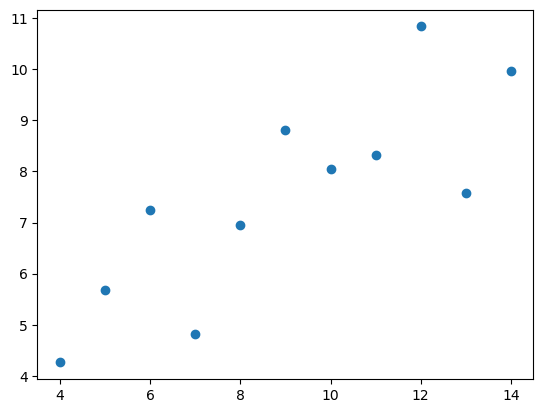

In [6]:
# TODO: put your code here
filtered = df.loc[df['Series'] == 'I']
plt.scatter(x='X', y='Y', data=filtered)

## Some histograms with pandas 

Let's look at a slightly more complicated dataset.

In [7]:
car_df = local_data.cars().astype({"Year": "object"})
car_df.head()

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01 00:00:00,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01 00:00:00,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01 00:00:00,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01 00:00:00,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01 00:00:00,USA


Pandas provides useful summary functions. It identifies numerical data columns and provides you with a table of summary statistics. 

In [8]:
car_df.describe()

,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration
count,398.000000,406.000000,406.000000,400.000000,406.000000,406.000000
mean,23.514573,5.475369,194.779557,105.082500,2979.413793,15.519704
std,7.815984,1.712160,104.922458,38.768779,847.004328,2.803359
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.500000,4.000000,105.000000,75.750000,2226.500000,13.700000
50%,23.000000,4.000000,151.000000,95.000000,2822.500000,15.500000
75%,29.000000,8.000000,302.000000,130.000000,3618.250000,17.175000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


If you ask to draw a histogram, you get all of them.

array([[<Axes: title={'center': 'Miles_per_Gallon'}>,
        <Axes: title={'center': 'Cylinders'}>],
       [<Axes: title={'center': 'Displacement'}>,
        <Axes: title={'center': 'Horsepower'}>],
       [<Axes: title={'center': 'Weight_in_lbs'}>,
        <Axes: title={'center': 'Acceleration'}>]], dtype=object)

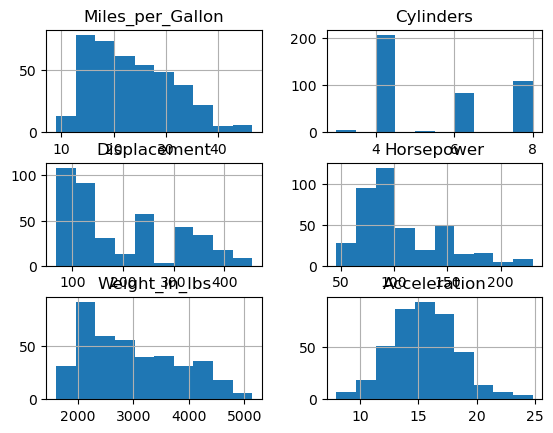

In [9]:
car_df.hist()

This is too small. You can check out [the documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.hist.html) and change the size of the figure. 

**Q2: by consulting the documentation, can you make the figure larger so that we can see all the labels clearly? And then make the layout 2 x 3 not 3 x 2. Then change the number of bins to 20?**

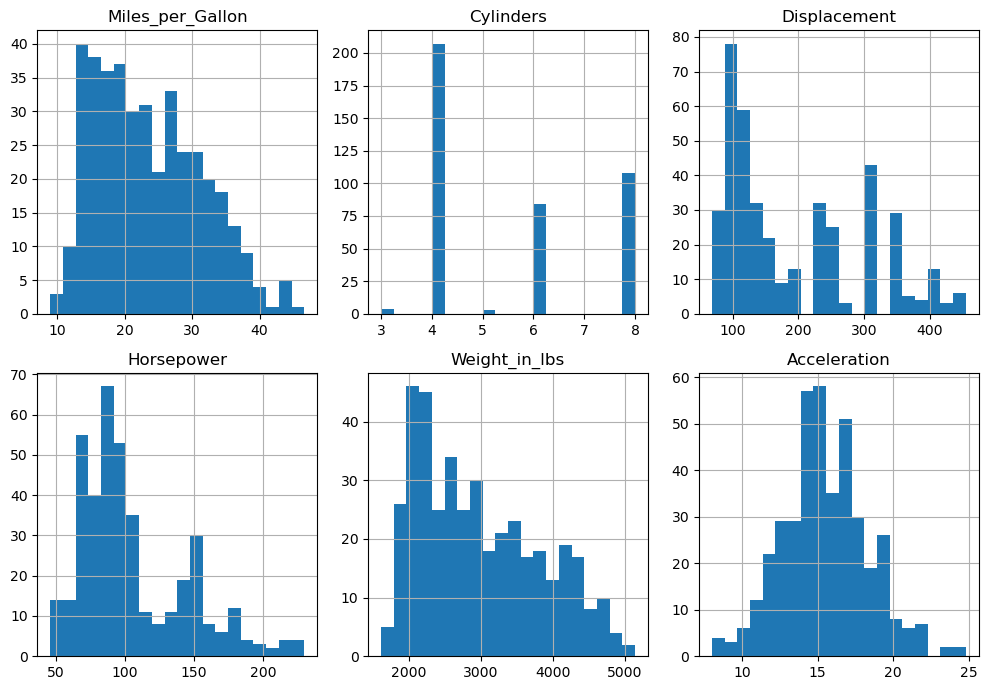

In [10]:
# TODO: put your code here
car_df.hist(bins=20, layout=(2,3),figsize=(10,7))
plt.tight_layout()
plt.show()

## Steven's power-law and your own psychophysics experiment!

Let's do an experiment! The procedure is as follows:

1. Generate a random number between \[1, 10\];
1. Use a horizontal bar to represent the number, i.e., the length of the bar is equal to the number;
1. Guess the length of the bar by comparing it to two other bars with length 1 and 10 respectively;
1. Store your guess (perceived length) and actual length to two separate lists;
1. Repeat the above steps many times;
1. How does the perception of length differ from that of area?.

First, let's define the length of a short and a long bar. We also create two empty lists to store perceived and actual length.

In [11]:
import random
import time
import numpy as np

l_short_bar = 1
l_long_bar = 10

perceived_length_list = []
actual_length_list = []

### Perception of length

Let's run the experiment.

The [**`random`**](https://docs.python.org/3.6/library/random.html) module in Python provides various random number generators, and the [**`random.uniform(a,b)`**](https://docs.python.org/3.6/library/random.html#random.uniform) function returns a floating point number in \[a,b\]. 

We can plot horizontal bars using the [**`pyplot.barh()`**](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.barh) function. Using this function, we can produce a bar graph that looks like this:

([], [])

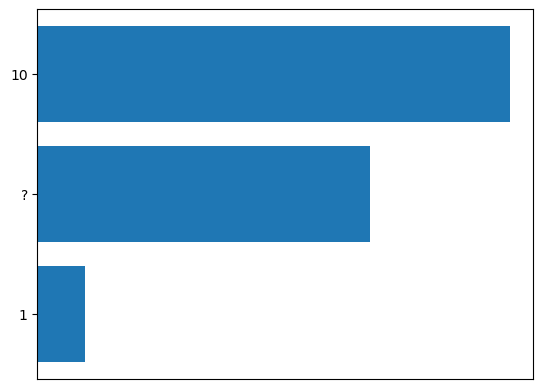

In [12]:
mystery_length = random.uniform(
    1, 10
)  # generate a number between 1 and 10. this is the *actual* length.

plt.barh(np.arange(3), [l_short_bar, mystery_length, l_long_bar], align="center")
plt.yticks(np.arange(3), ("1", "?", "10"))
plt.xticks([])  # no hint!

Now let's define a function to perform the experiment once. When you run this function, it picks a random number between 1.0 and 10.0 and show the bar chart. Then it asks you to input your estimate of the length of the middle bar. It then saves that number to the `perceived_length_list` and the actual answer to the `actual_length_list`. 

Note, if the input box does not appear for you try (1) switching to firefox, OR (2) removing the input line from the code and manually record the numbers in a cell, OR (3) adding a prompt to it like input("enter estimation")

In [13]:
def run_exp_once():
    mystery_length = random.uniform(1, 10)  # generate a number between 1 and 10.

    plt.barh(
        np.arange(3),
        [l_short_bar, mystery_length, l_long_bar],
        height=0.5,
        align="center",
    )
    plt.yticks(np.arange(3), ("1", "?", "10"))
    plt.xticks([])  # no hint!
    plt.show()

    try:
        perceived_length_list.append(float(input()))
    except:
        print(
            "This should only fail in workflow. If you are running this in browser, this won't fail."
        )
        pass
    actual_length_list.append(mystery_length)

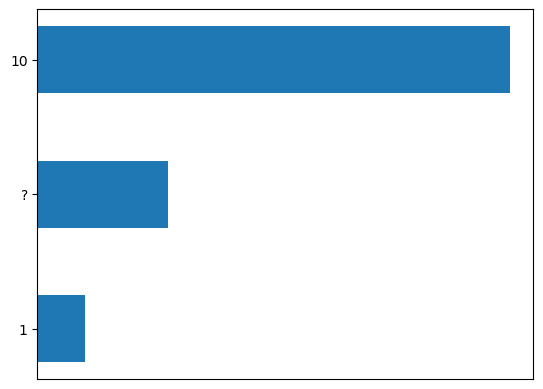

In [14]:
run_exp_once()

Now, run the experiment many times to gather your data. Check the two lists to make sure that you have the proper dataset. The length of the two lists should be the same. 

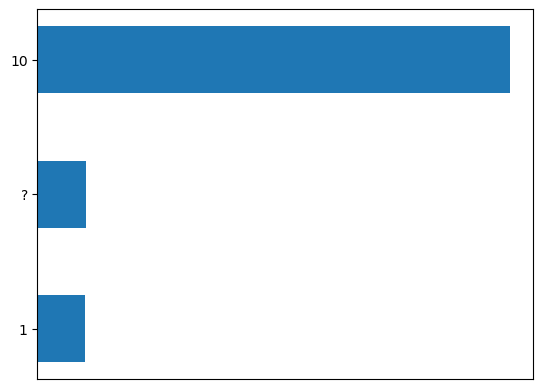

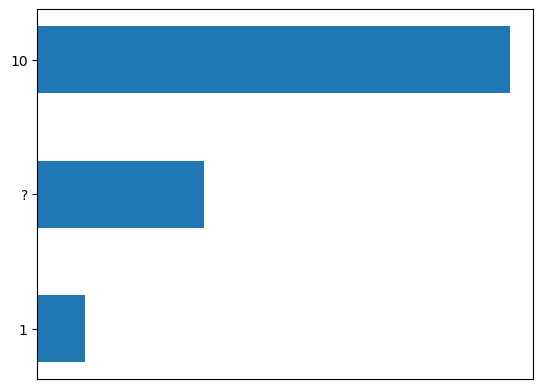

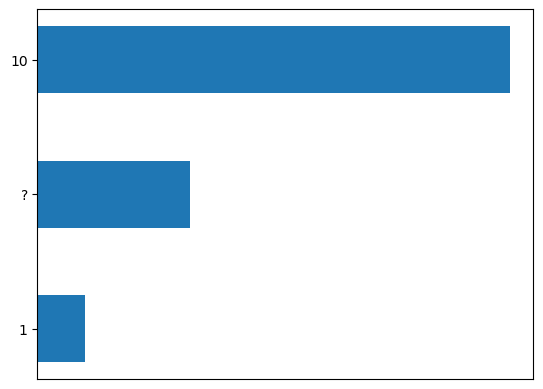

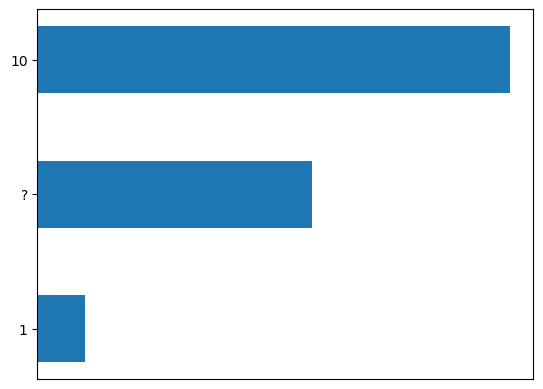

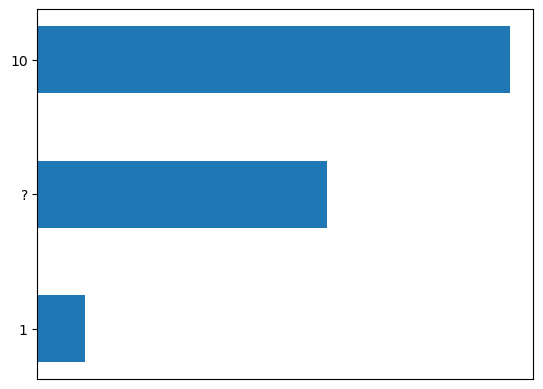

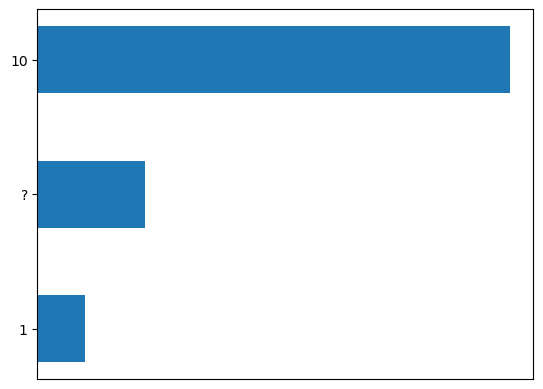

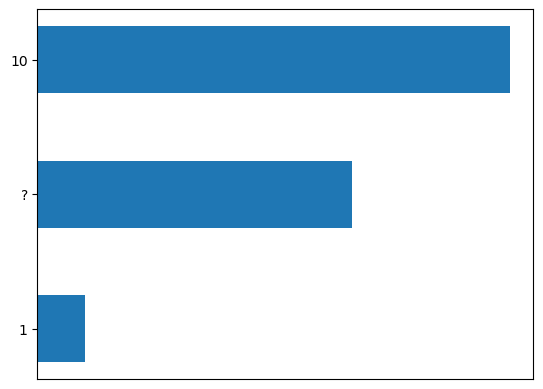

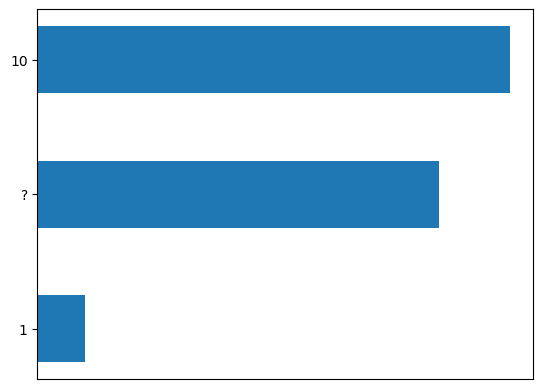

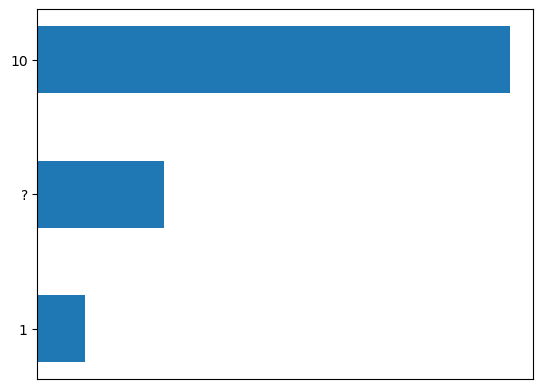

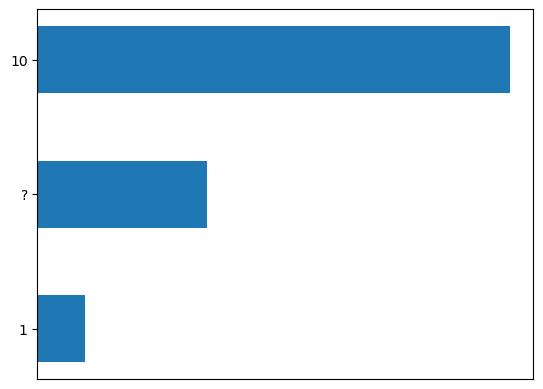

Lists have the same length: True


In [15]:
# TODO: Run your experiment many times here
for _ in range(10):
    run_exp_once()
print("Lists have the same length:", len(perceived_length_list) == len(actual_length_list))

### Plotting the result

Now we can draw the scatter plot of perceived and actual length. The `matplotlib`'s [**`scatter()`**](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter) function will do this. This is the backend of the pandas' scatterplot. Here is an example of how to use `scatter`:

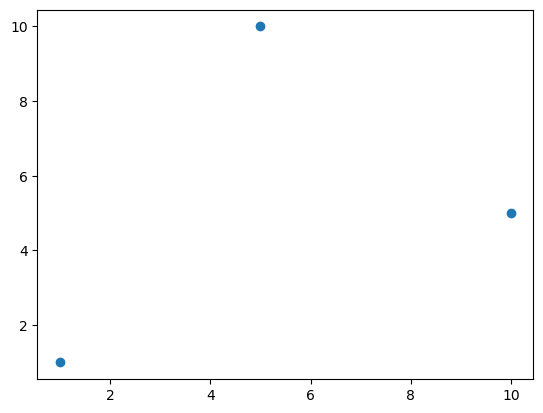

In [16]:
plt.scatter(x=[1, 5, 10], y=[1, 10, 5])

**Q3: Plot your result using the `scatter()` function. You should also use `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` to label your axes and the plot itself.**

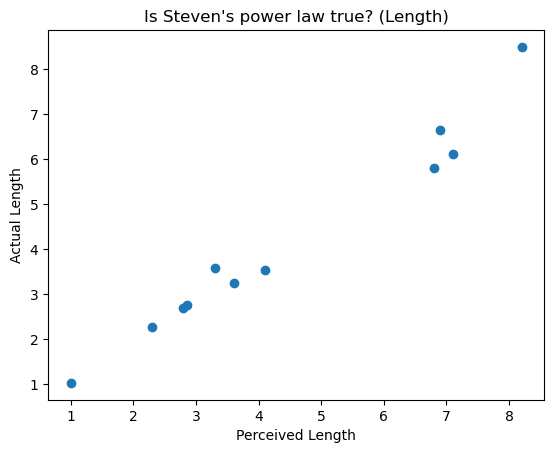

In [17]:
# TODO: put your code here
plt.scatter(x=perceived_length_list, y=actual_length_list)
plt.xlabel("Perceived Length")
plt.ylabel("Actual Length")
plt.title("Is Steven's power law true? (Length)")
plt.show()

After plotting, let's fit the relation between actual and perceived lengths using a polynomial function. We can easily do it using [**`curve_fit(f, x, y)`**](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) in Scipy, which is to fit $x$ and $y$ using the function `f`. In our case, $f = a*x^b +c$. For instance, we can check whether this works by creating a fake dataset that follows the exact form:

In [18]:
from scipy.optimize import curve_fit


def func(x, a, b, c):
    return a * np.power(x, b) + c


x = np.arange(20)  # [0,1,2,3, ..., 19]
y = np.power(x, 2)  # [0,1,4,9, ... ]

popt, pcov = curve_fit(func, x, y)
print("{:.2f} x^{:.2f} + {:.2f}".format(*popt))

1.00 x^2.00 + -0.00


In order to plot the function to check the relationship between the actual and perceived lenghts, you can use two variables `x` and `y` to plot the relationship where `x` equals to a series of continuous numbers. For example, if your x axis ranges from 1 to 9 then the variable `x` could be equal to `np.linspace(1, 10, 50)`. The variable `y` will contain the equation that you get from `popt`. For example, if you get equation `1.00 x^2.00 + 0.00` then the variable `y` would be equal to `1.0 * x**2.0 + 0`. 

After assigning `x` and `y` variables you will plot them in combination with the scatter plot of actual and perceived values to check if you get a linear relationship or not.

**Q4: Now fit your data!** Do you see roughly linear relationship between the actual and the perceived lengths? It's ok if you don't!

2.12 x^0.73 + -1.42


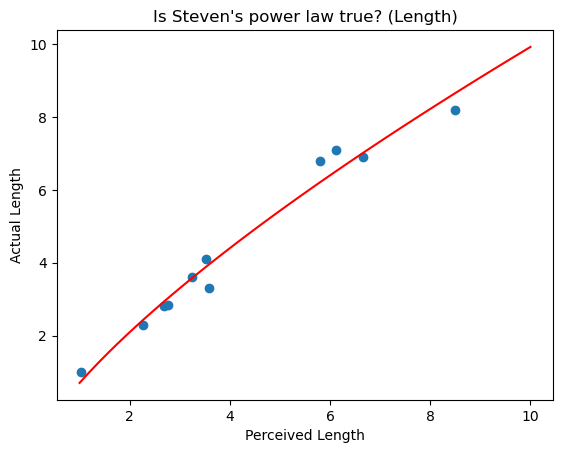

In [63]:
# TODO: your code here
param_length, param_cov_length = curve_fit(func, actual_length_list, perceived_length_list)
print("{:.2f} x^{:.2f} + {:.2f}".format(*param_length))
x_length = np.linspace(1, 10, 50)
y_length= func(x_length, *param_length)
plt.scatter( x=actual_length_list, y=perceived_length_list)
plt.plot(x_length, y_length, color='red')
plt.xlabel("Perceived Length")
plt.ylabel("Actual Length")
plt.title("Is Steven's power law true? (Length)")
plt.show()

### Perception of area

Similar to the above experiment, we now represent a random number as a circle, and the area of the circle is equal to the number.

First, calculate the radius of a circle from its area and then plot using the **`Circle()`** function. `plt.Circle((0,0), r)` will plot a circle centered at (0,0) with radius `r`.

aaa 7.613864900587227


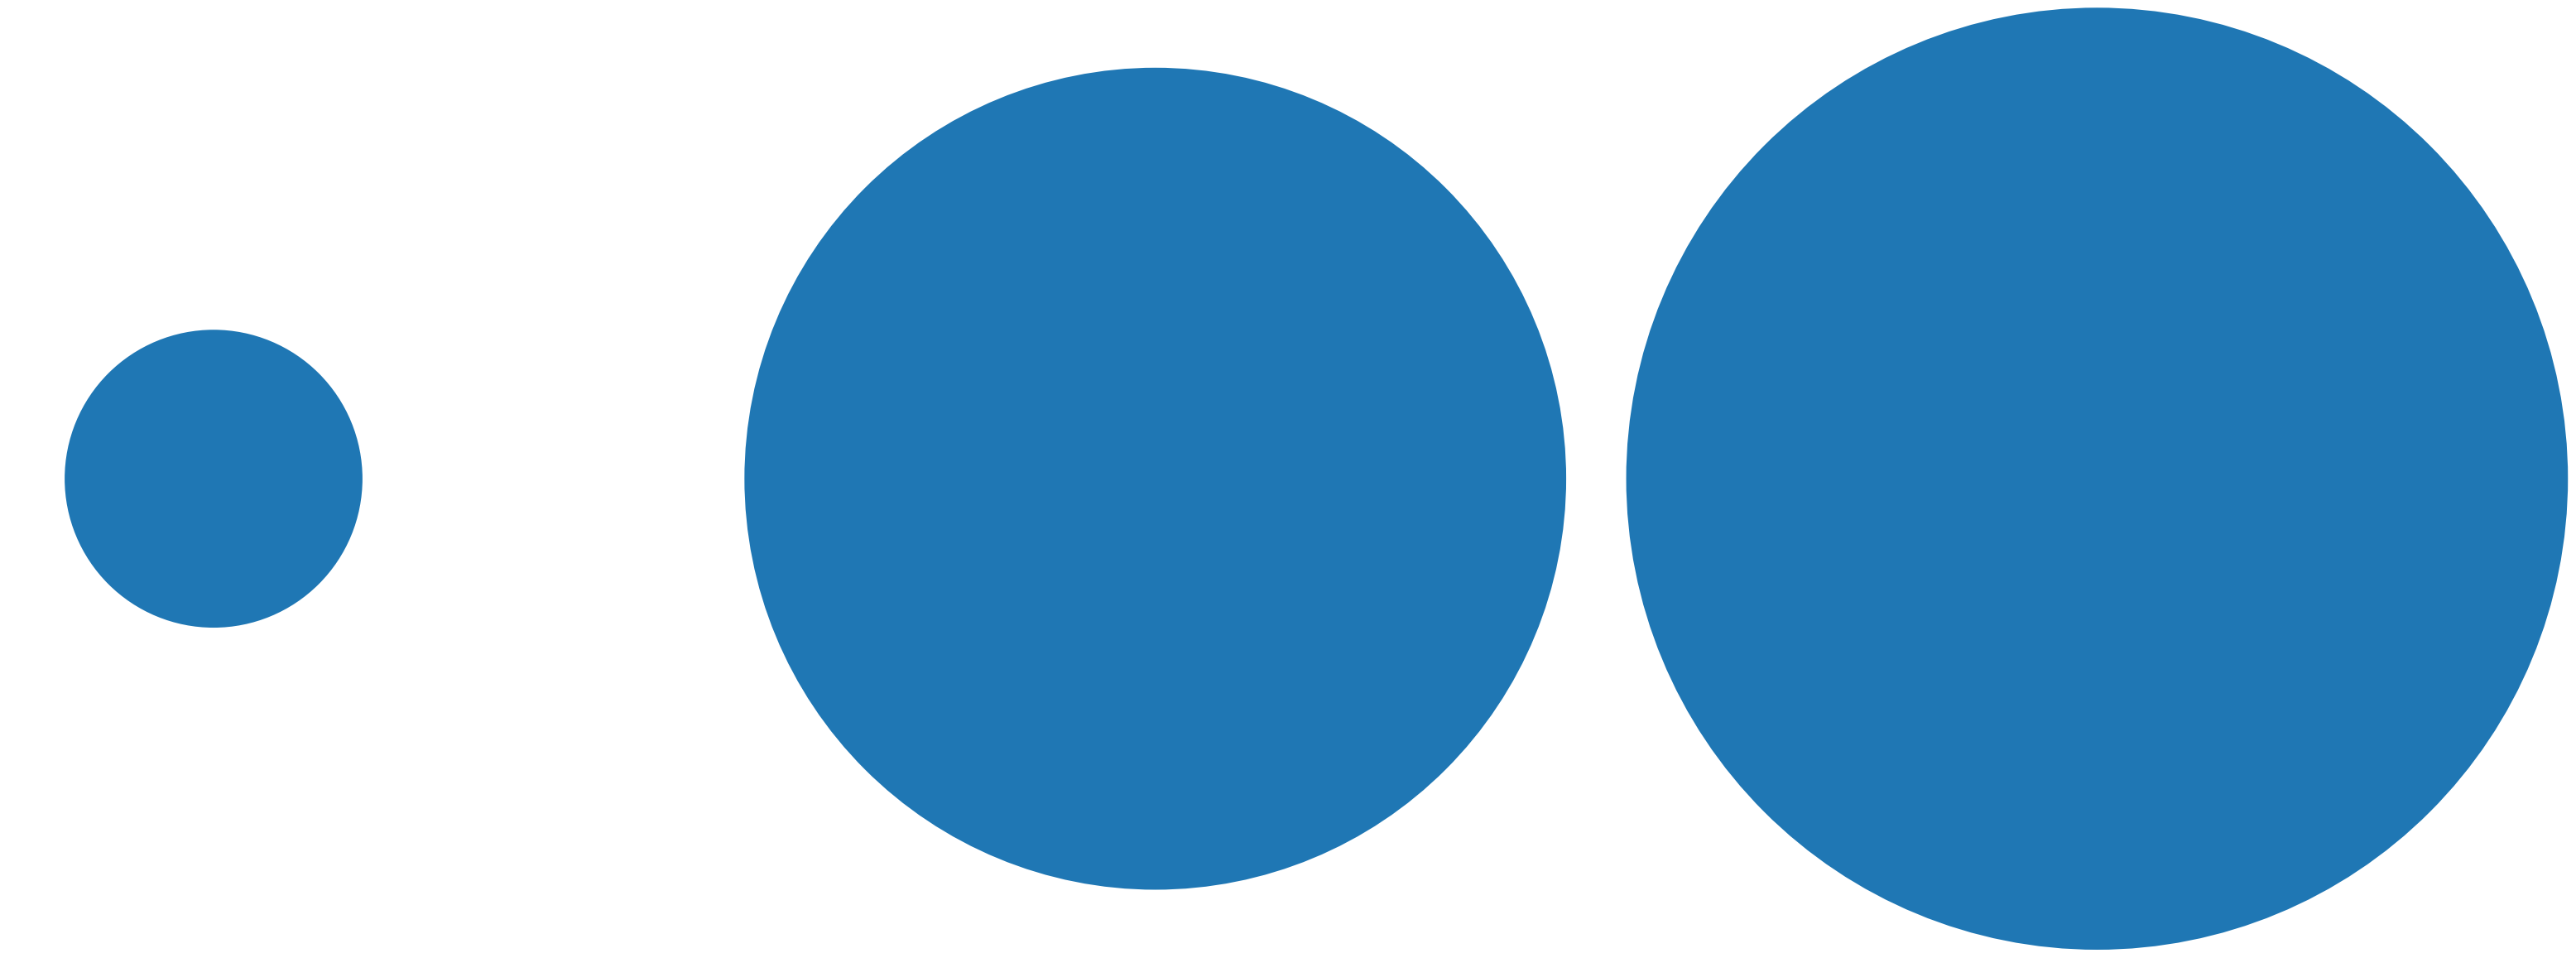

In [53]:
n1 = 0.005
n2 = 0.05

radius1 = np.sqrt(n1 / np.pi)  # area = pi * r * r
radius2 = np.sqrt(n2 / np.pi)
a =  random.uniform(1, 10)
random_radius = np.sqrt(n1 * a / np.pi)

plt.axis("equal")
plt.axis("off")
circ1 = plt.Circle((0, 0), radius1, clip_on=False)
circ2 = plt.Circle((4 * radius2, 0), radius2, clip_on=False)
rand_circ = plt.Circle((2 * radius2, 0), random_radius, clip_on=False)

plt.gca().add_artist(circ1)
plt.gca().add_artist(circ2)
plt.gca().add_artist(rand_circ)
print("aaa", a)

Let's have two lists for this experiment.  

In [29]:
perceived_area_list = []
actual_area_list = []

And define a function for the experiment. 

Note, if the input box does not appear for you try (1) switching to firefox, OR (2) removing the input line from the code and manually record the numbers in a cell, OR (3) adding a prompt to it like input("enter estimation")

In [34]:
def run_area_exp_once(n1=0.005, n2=0.05):
    radius1 = np.sqrt(n1 / np.pi)  # area = pi * r * r
    radius2 = np.sqrt(n2 / np.pi)

    mystery_number = random.uniform(1, 10)
    random_radius = np.sqrt(n1 * mystery_number / math.pi)

    plt.axis("equal")
    plt.axis("off")
    circ1 = plt.Circle((0, 0), radius1, clip_on=False)
    circ2 = plt.Circle((4 * radius2, 0), radius2, clip_on=False)
    rand_circ = plt.Circle((2 * radius2, 0), random_radius, clip_on=False)
    plt.gca().add_artist(circ1)
    plt.gca().add_artist(circ2)
    plt.gca().add_artist(rand_circ)
    plt.show()

    perceived_area_list.append(float(input()))
    actual_area_list.append(mystery_number)

**Q5: Now you can run the experiment many times, plot the result, and fit a power-law curve to test the Steven's power-law.** 

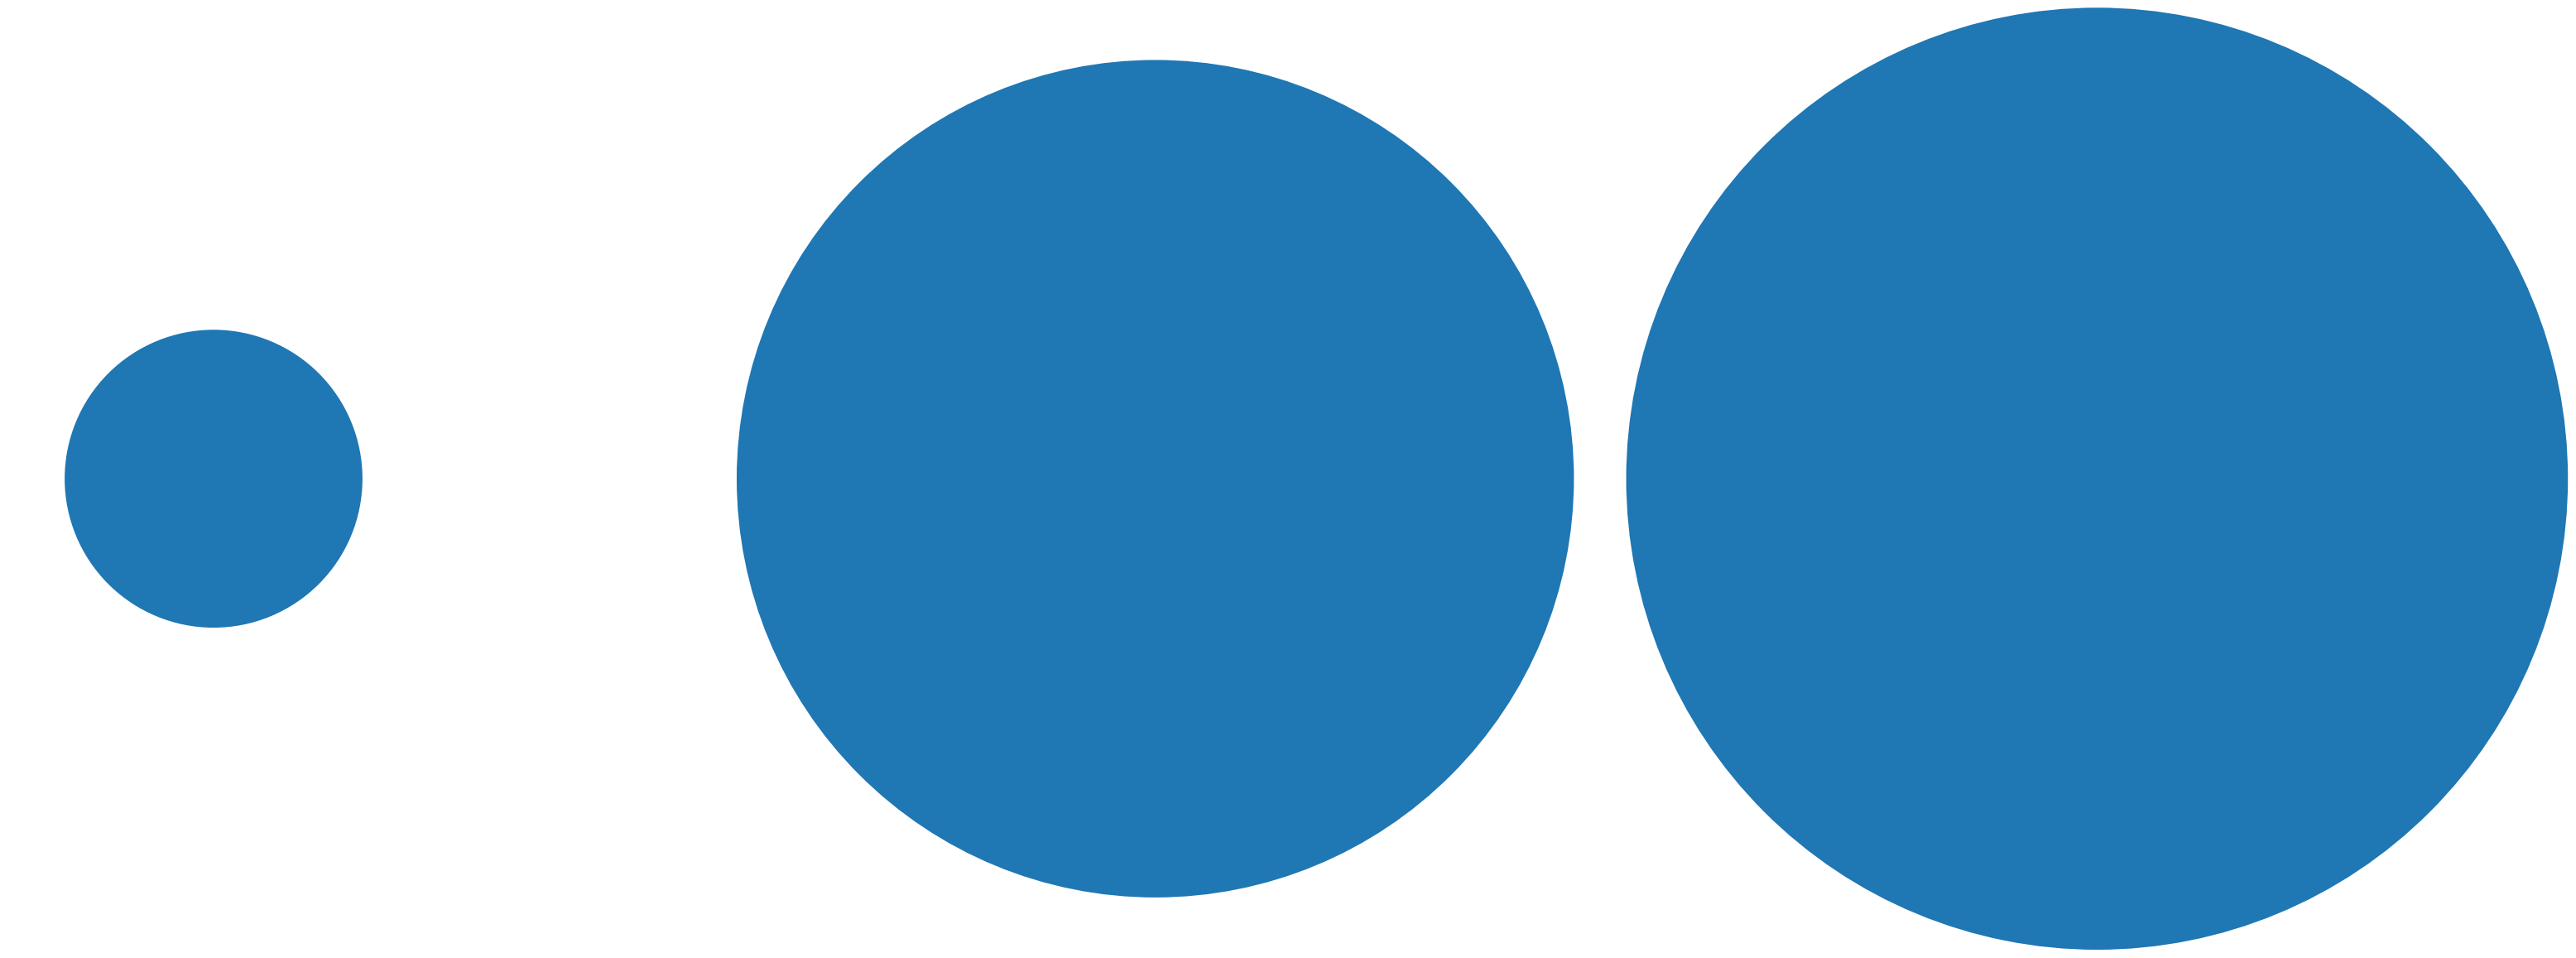

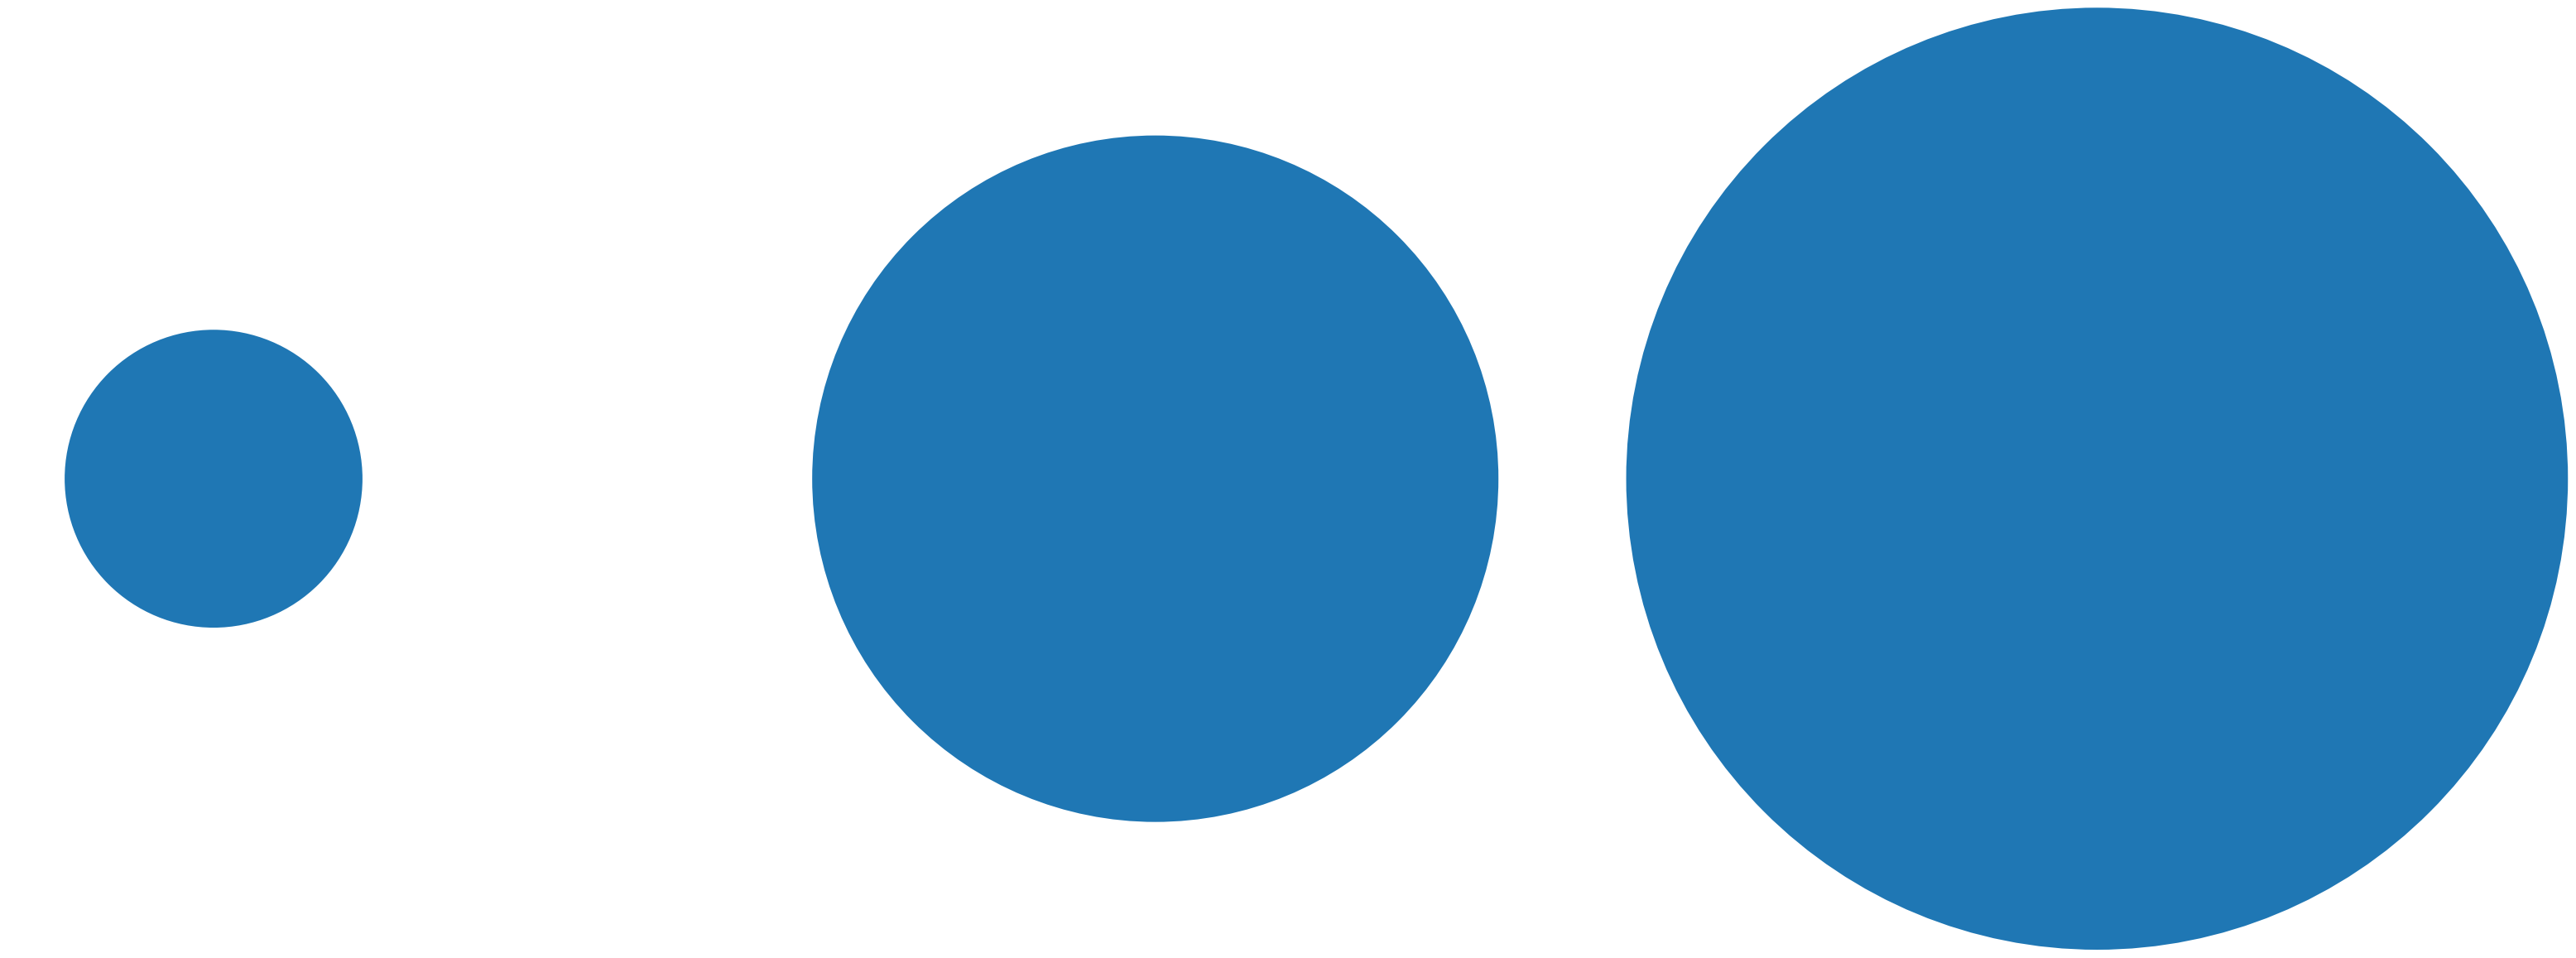

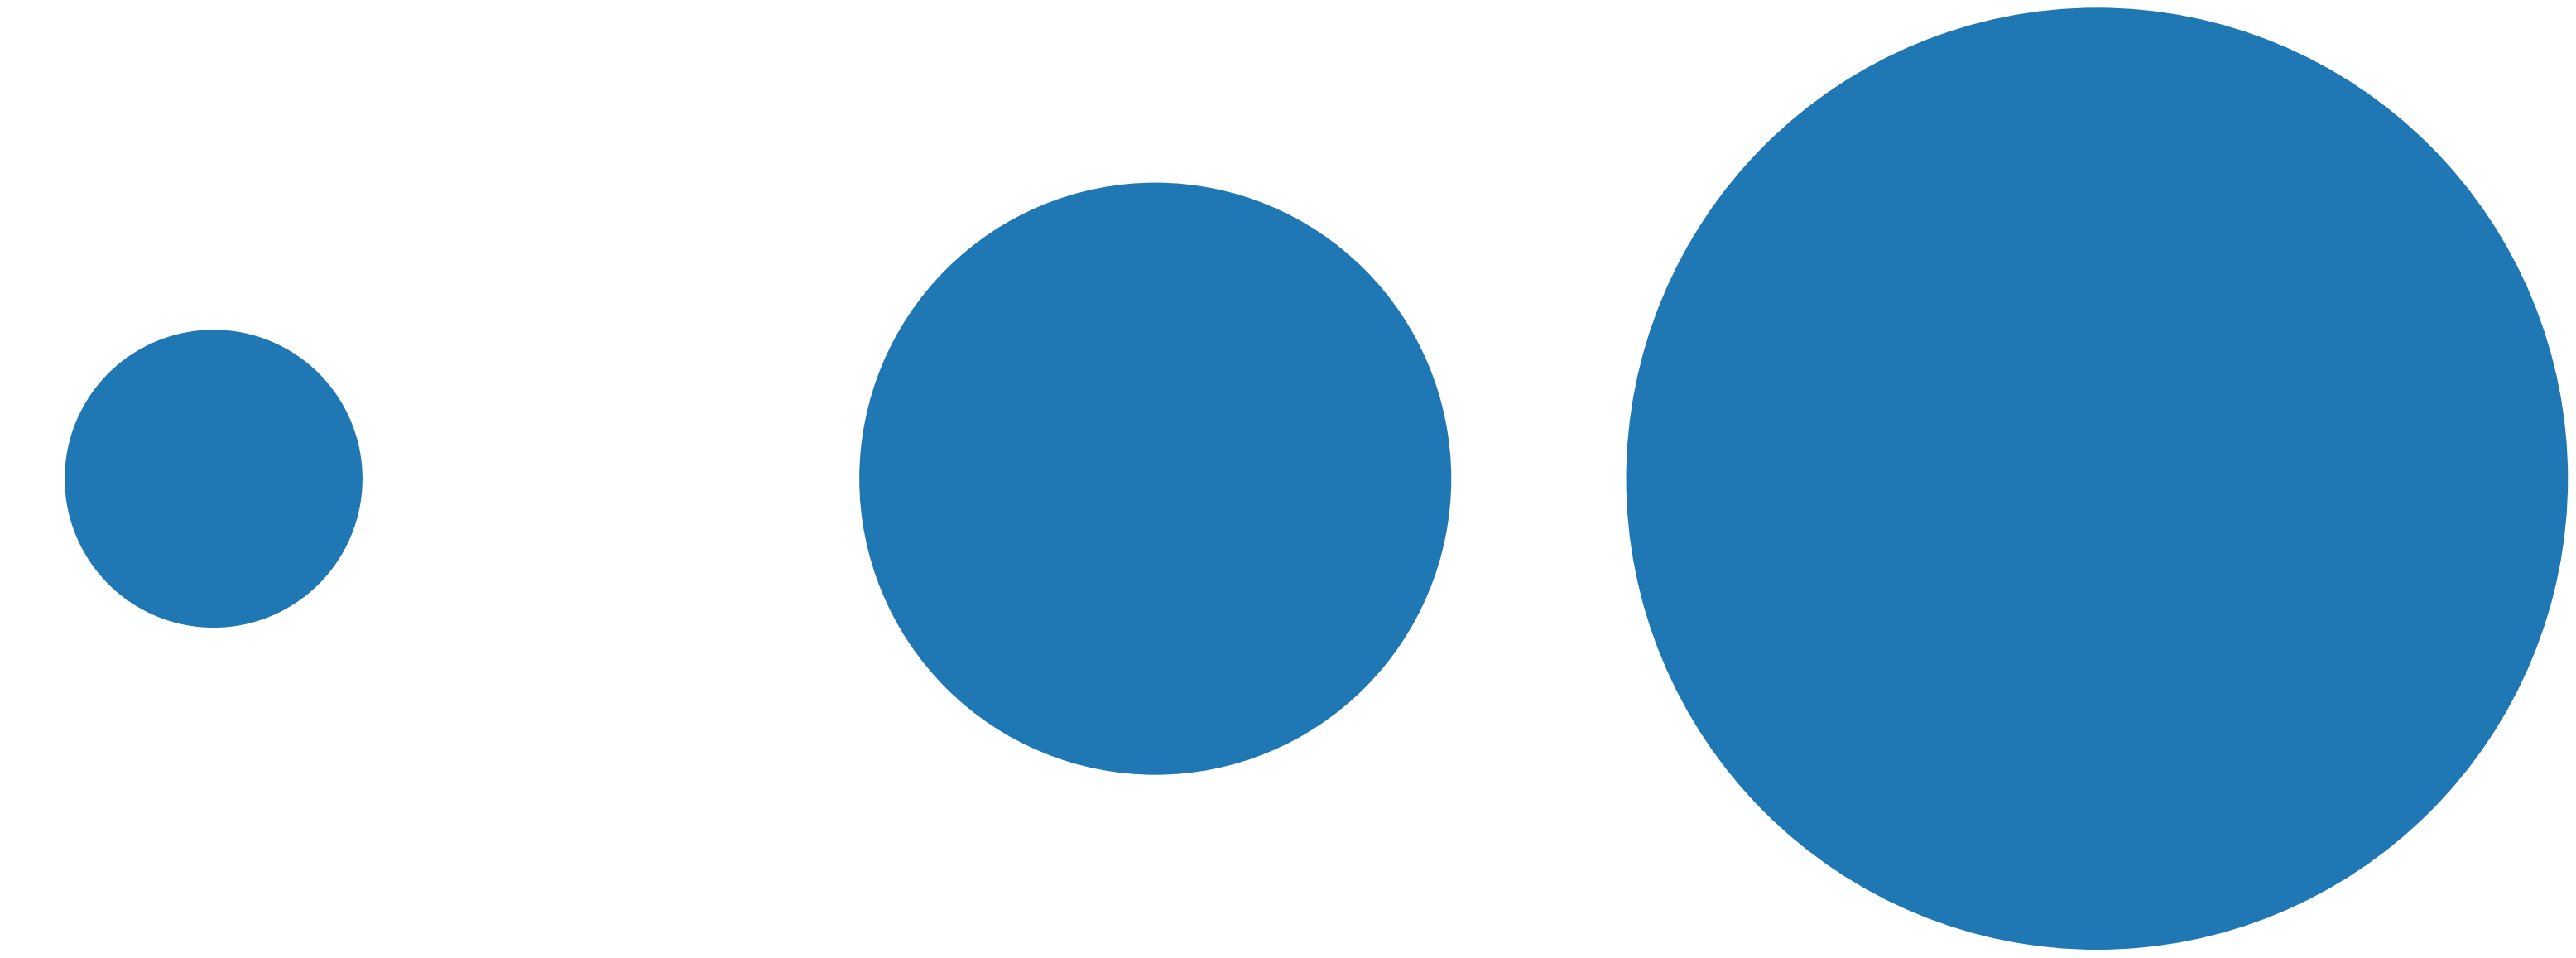

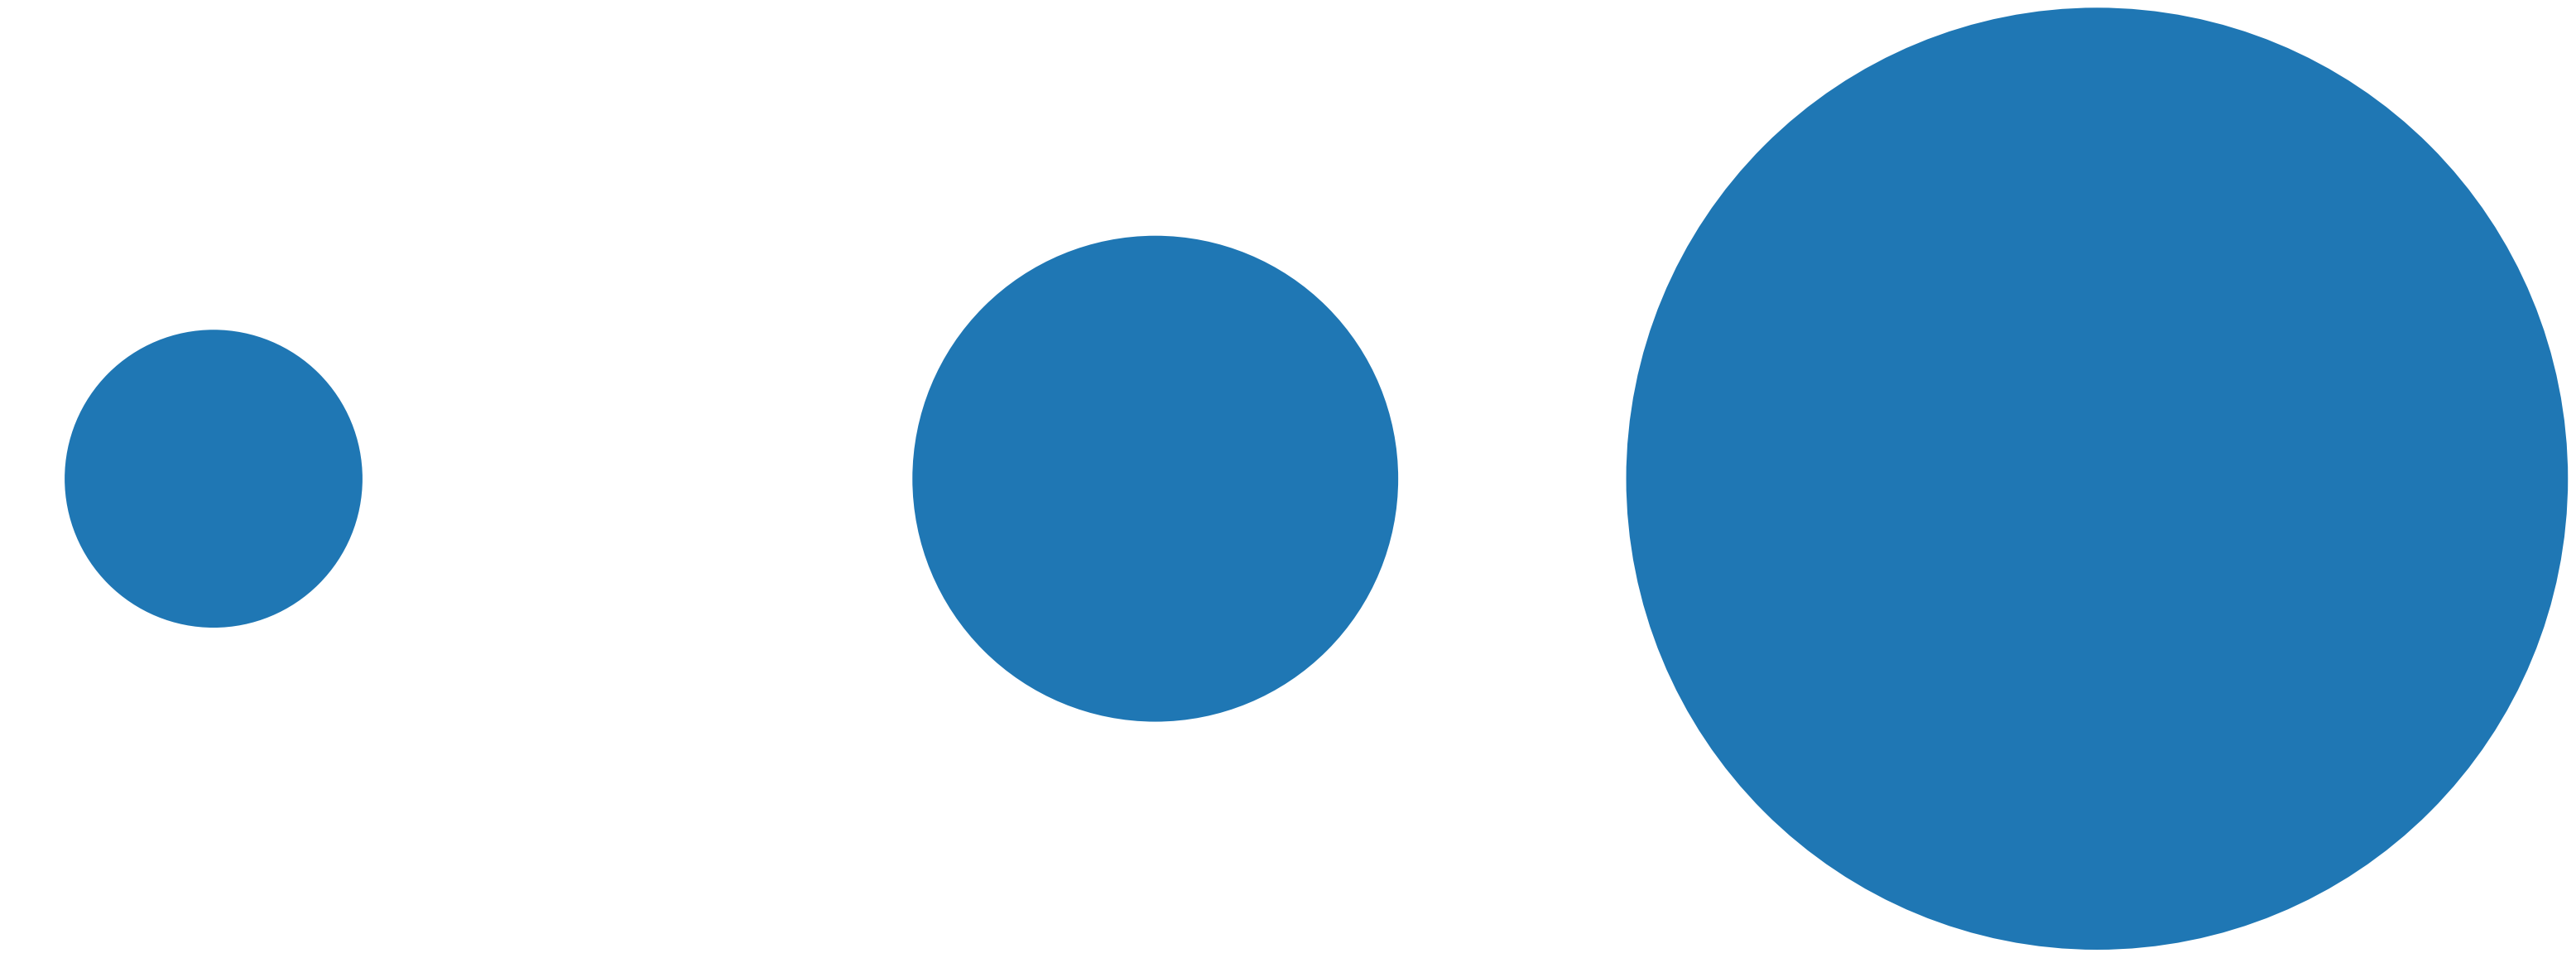

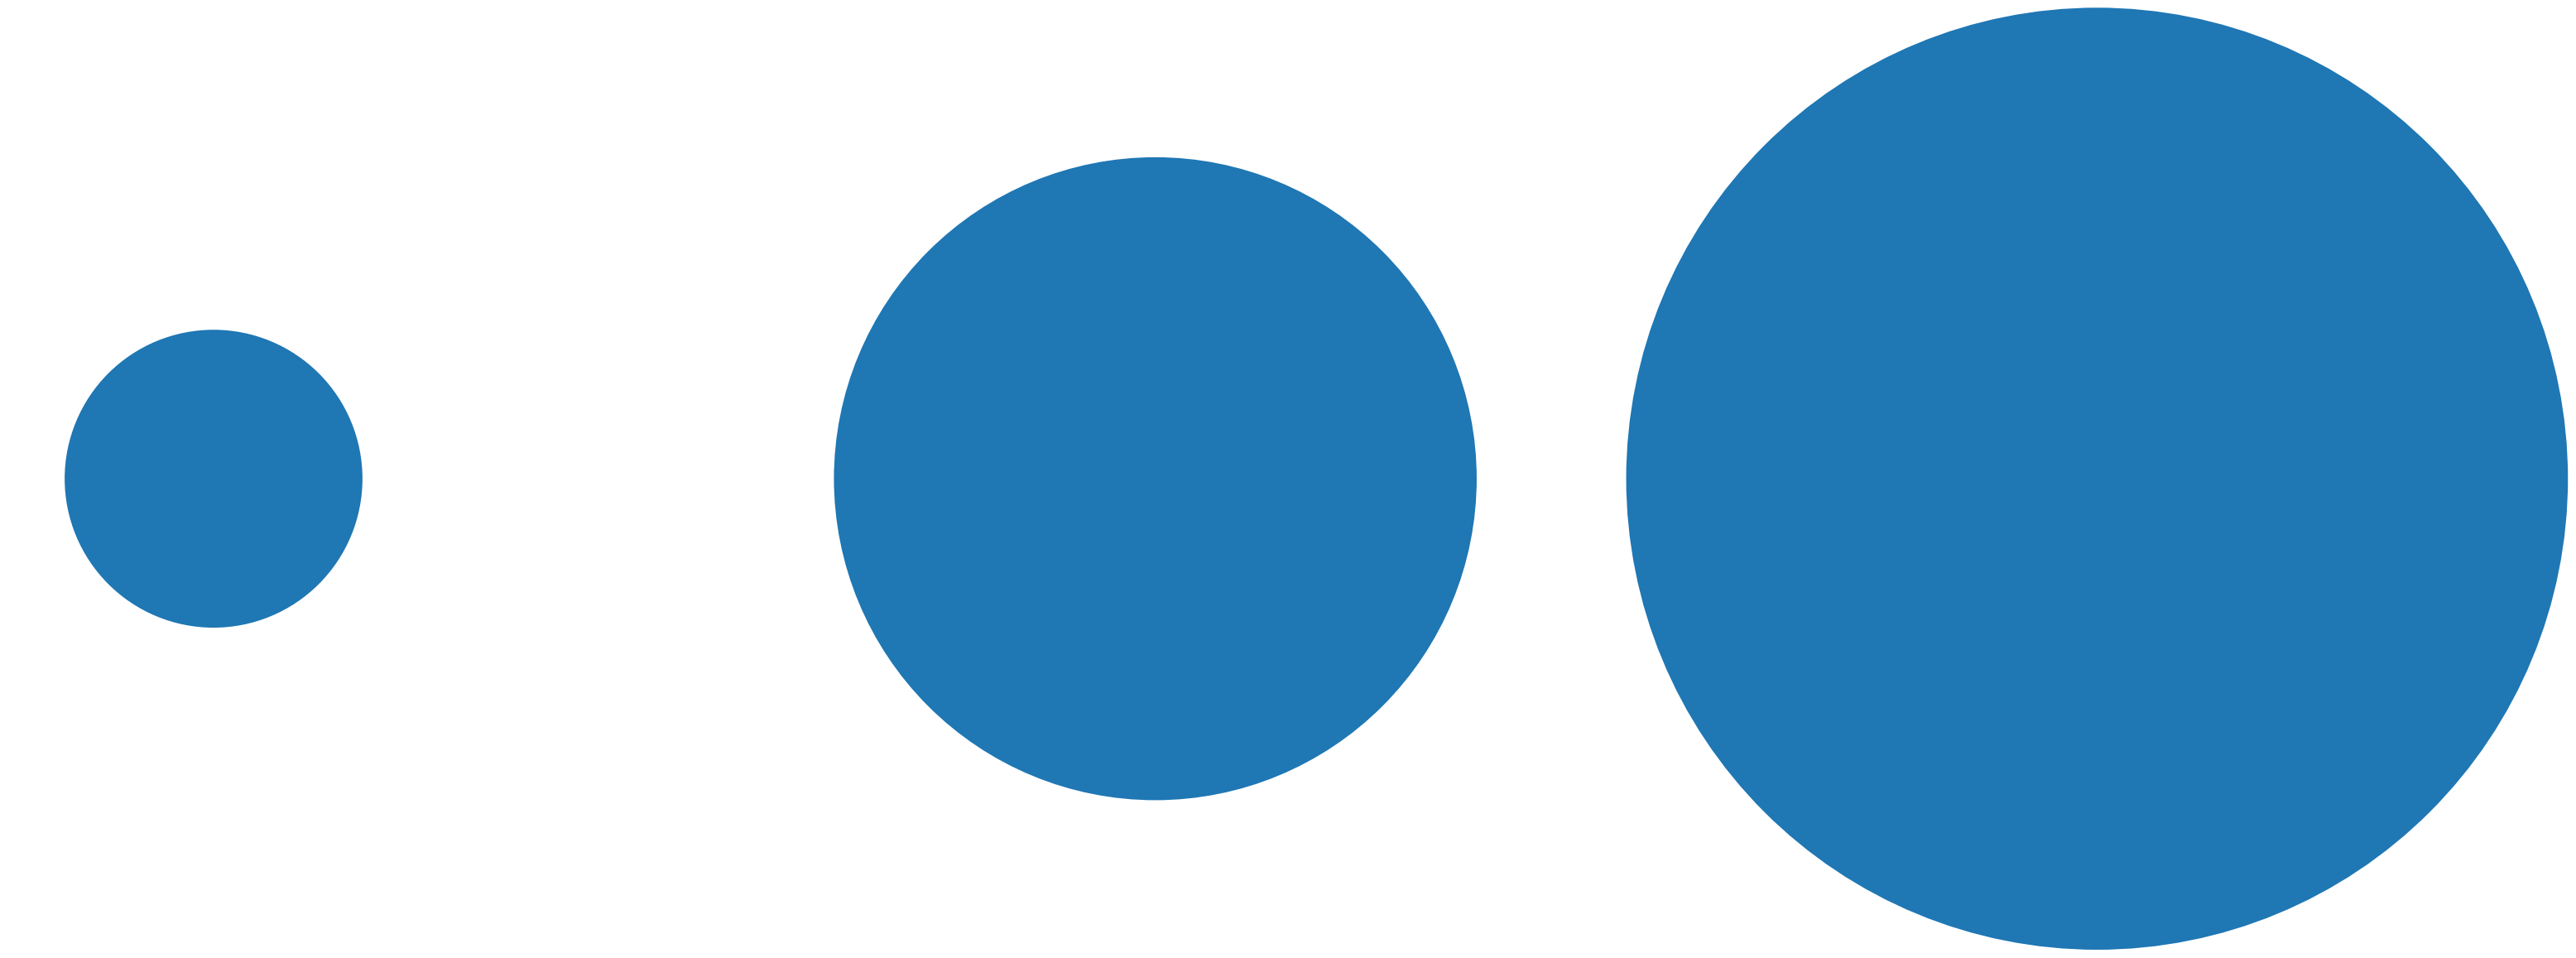

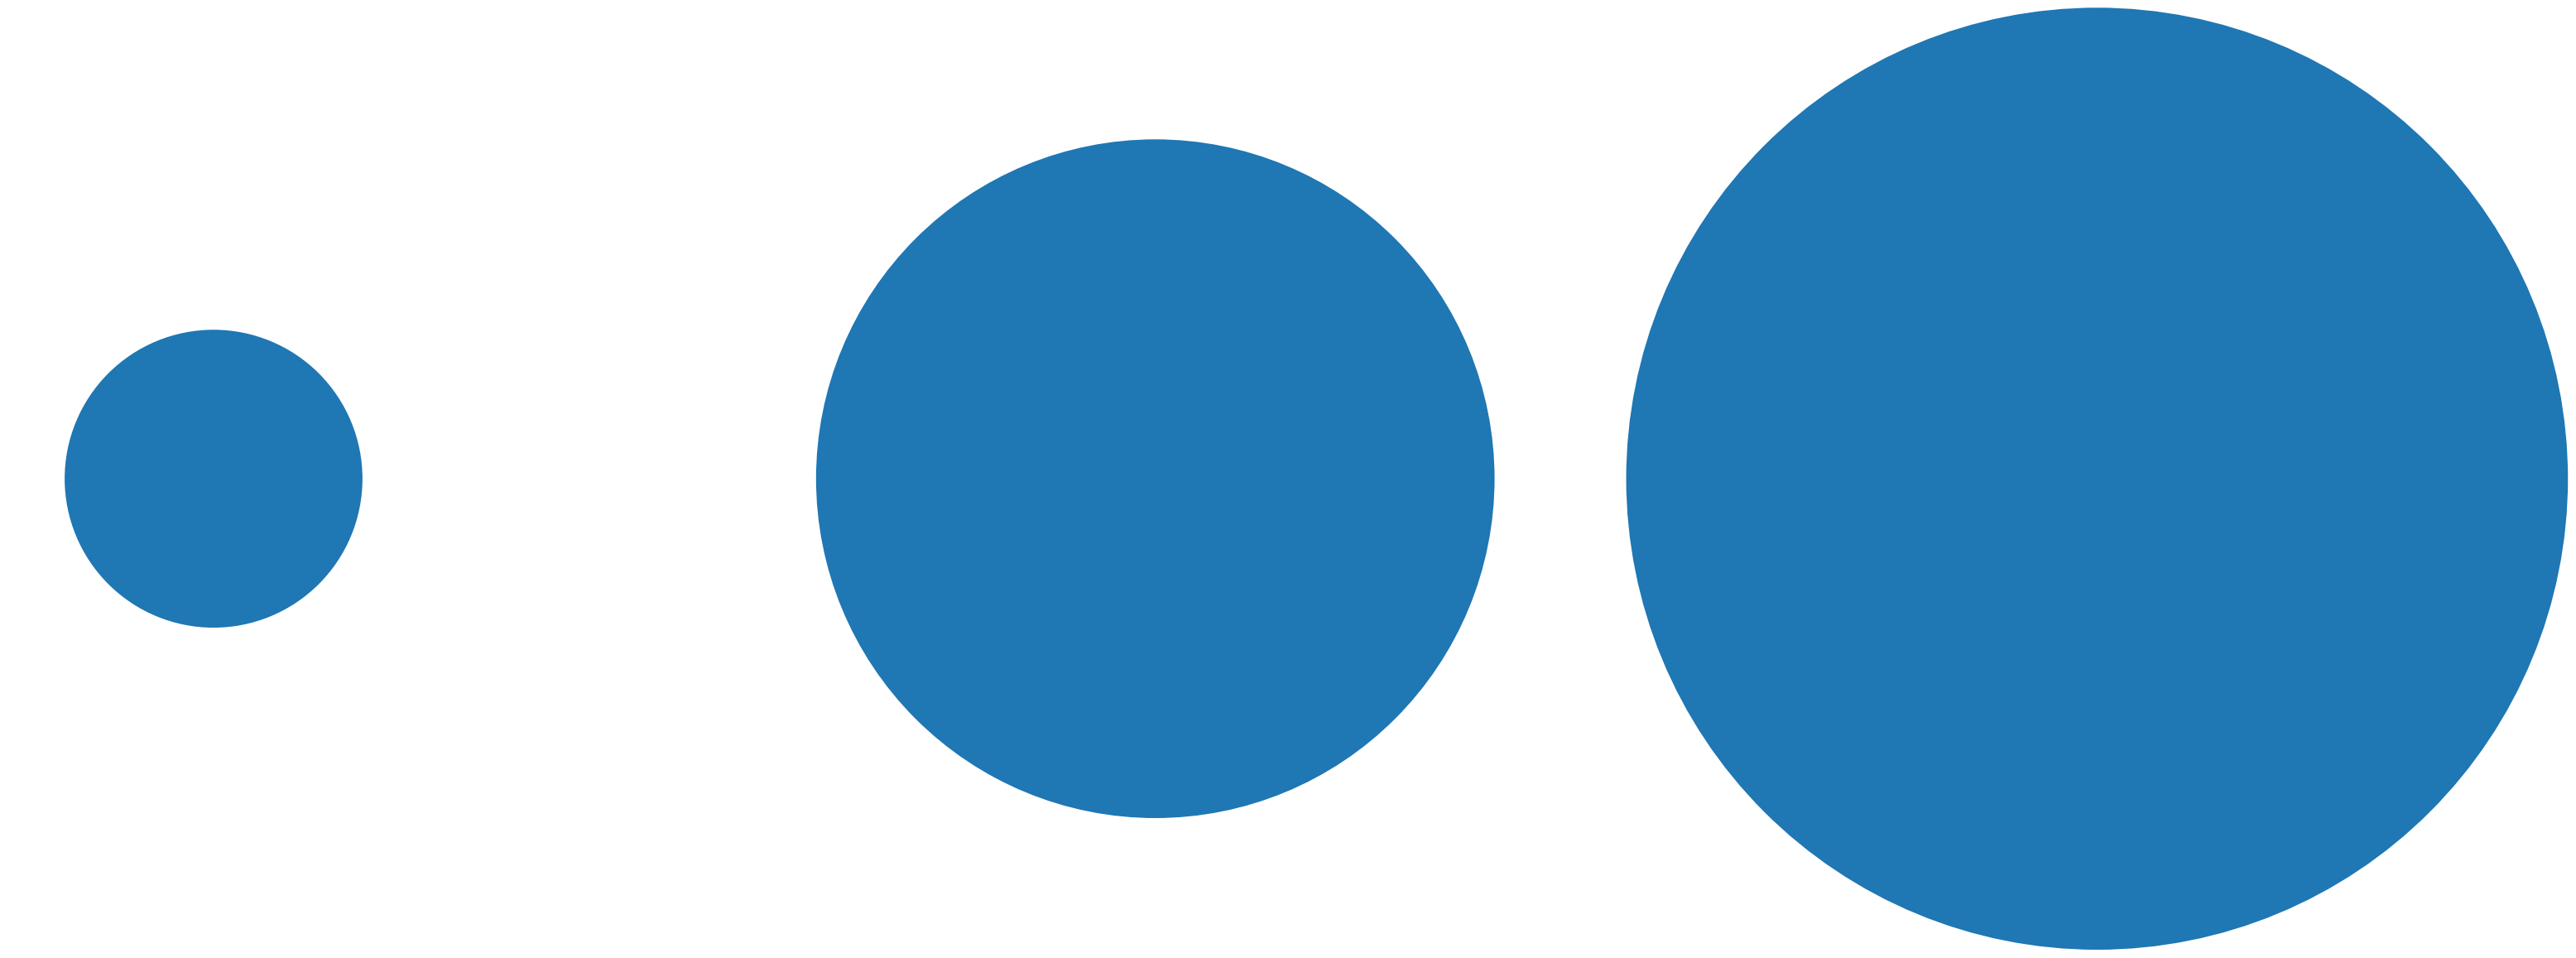

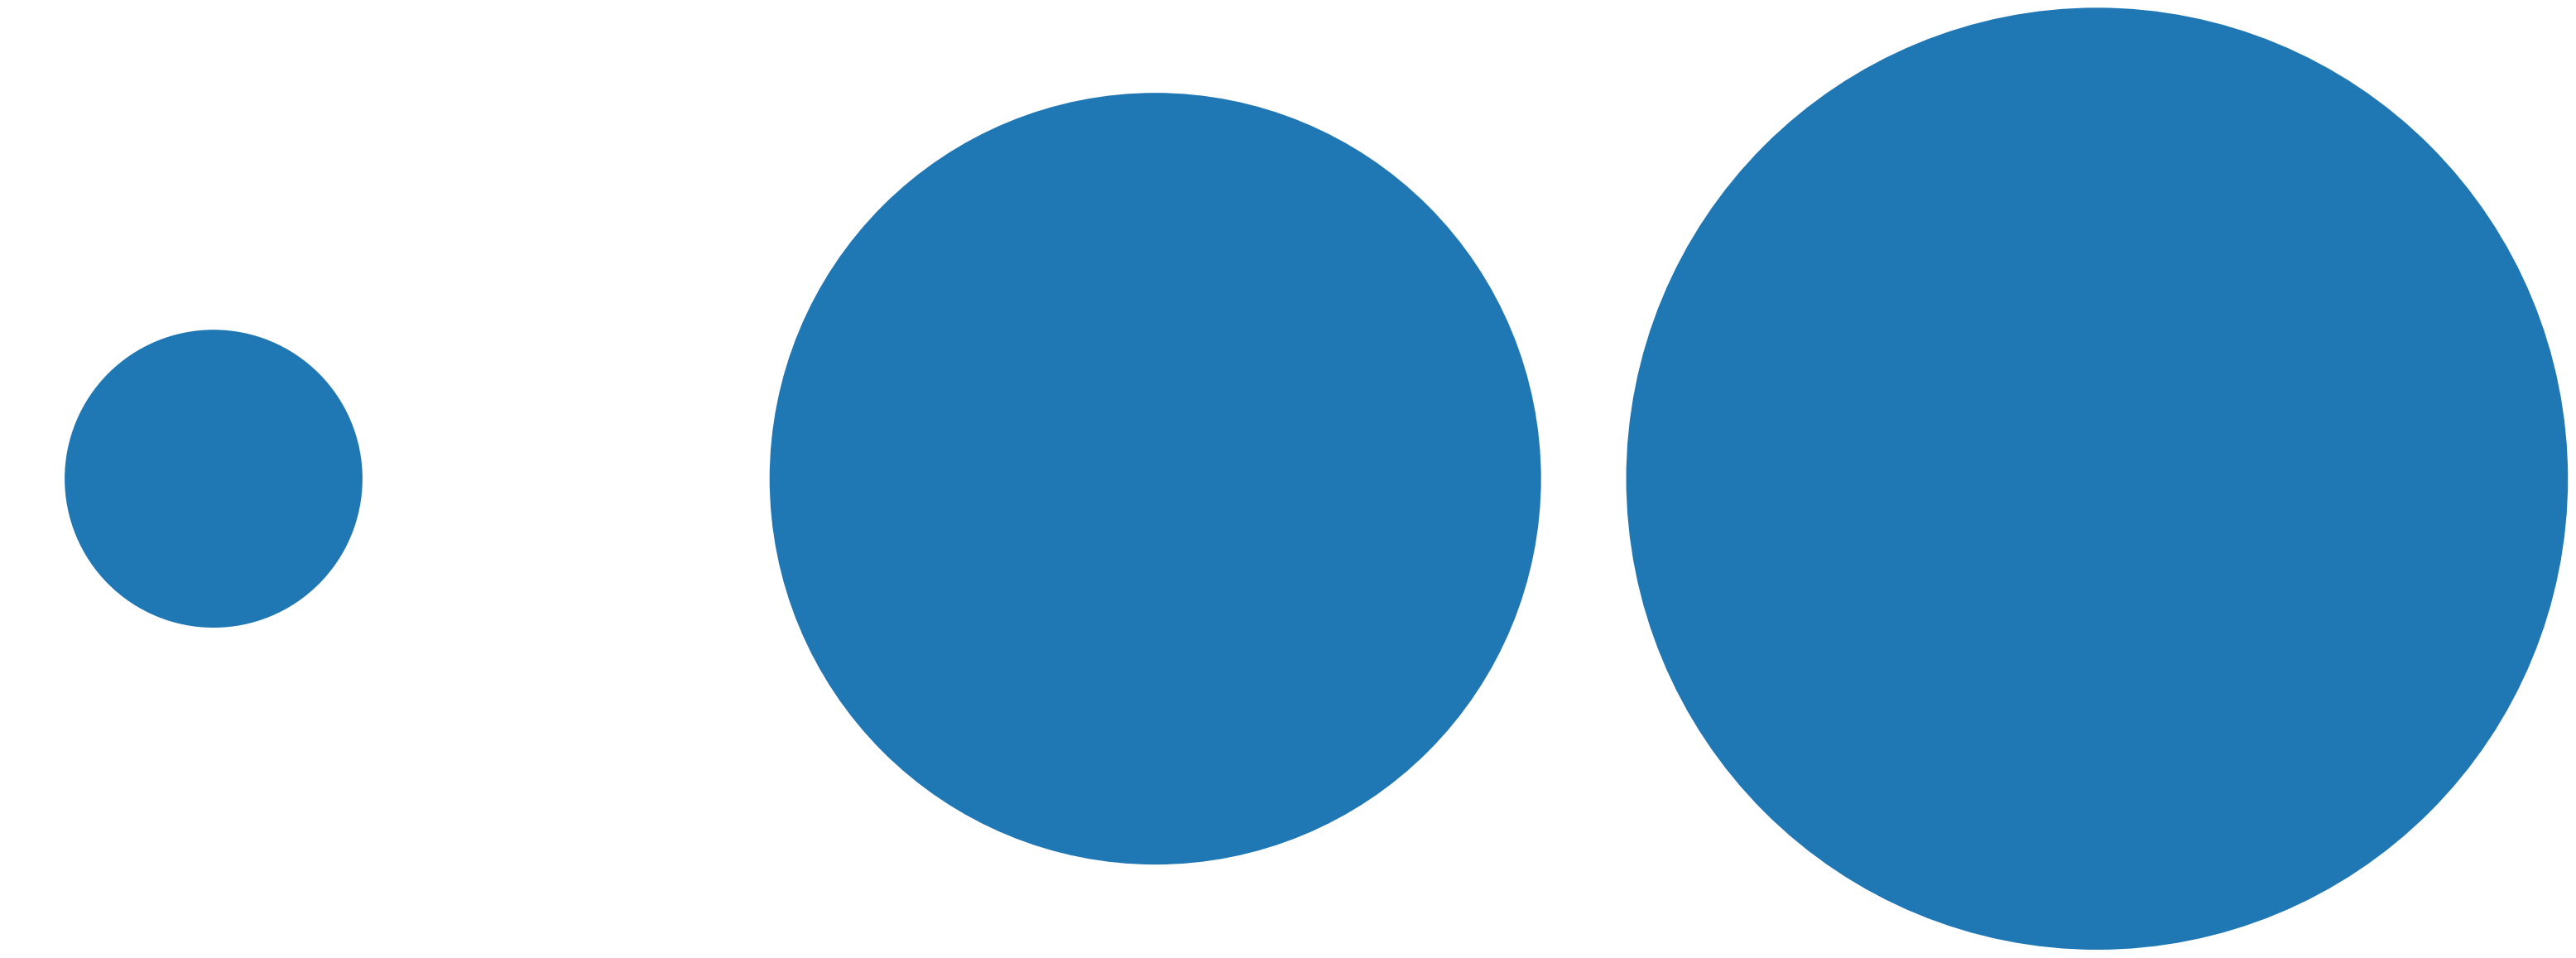

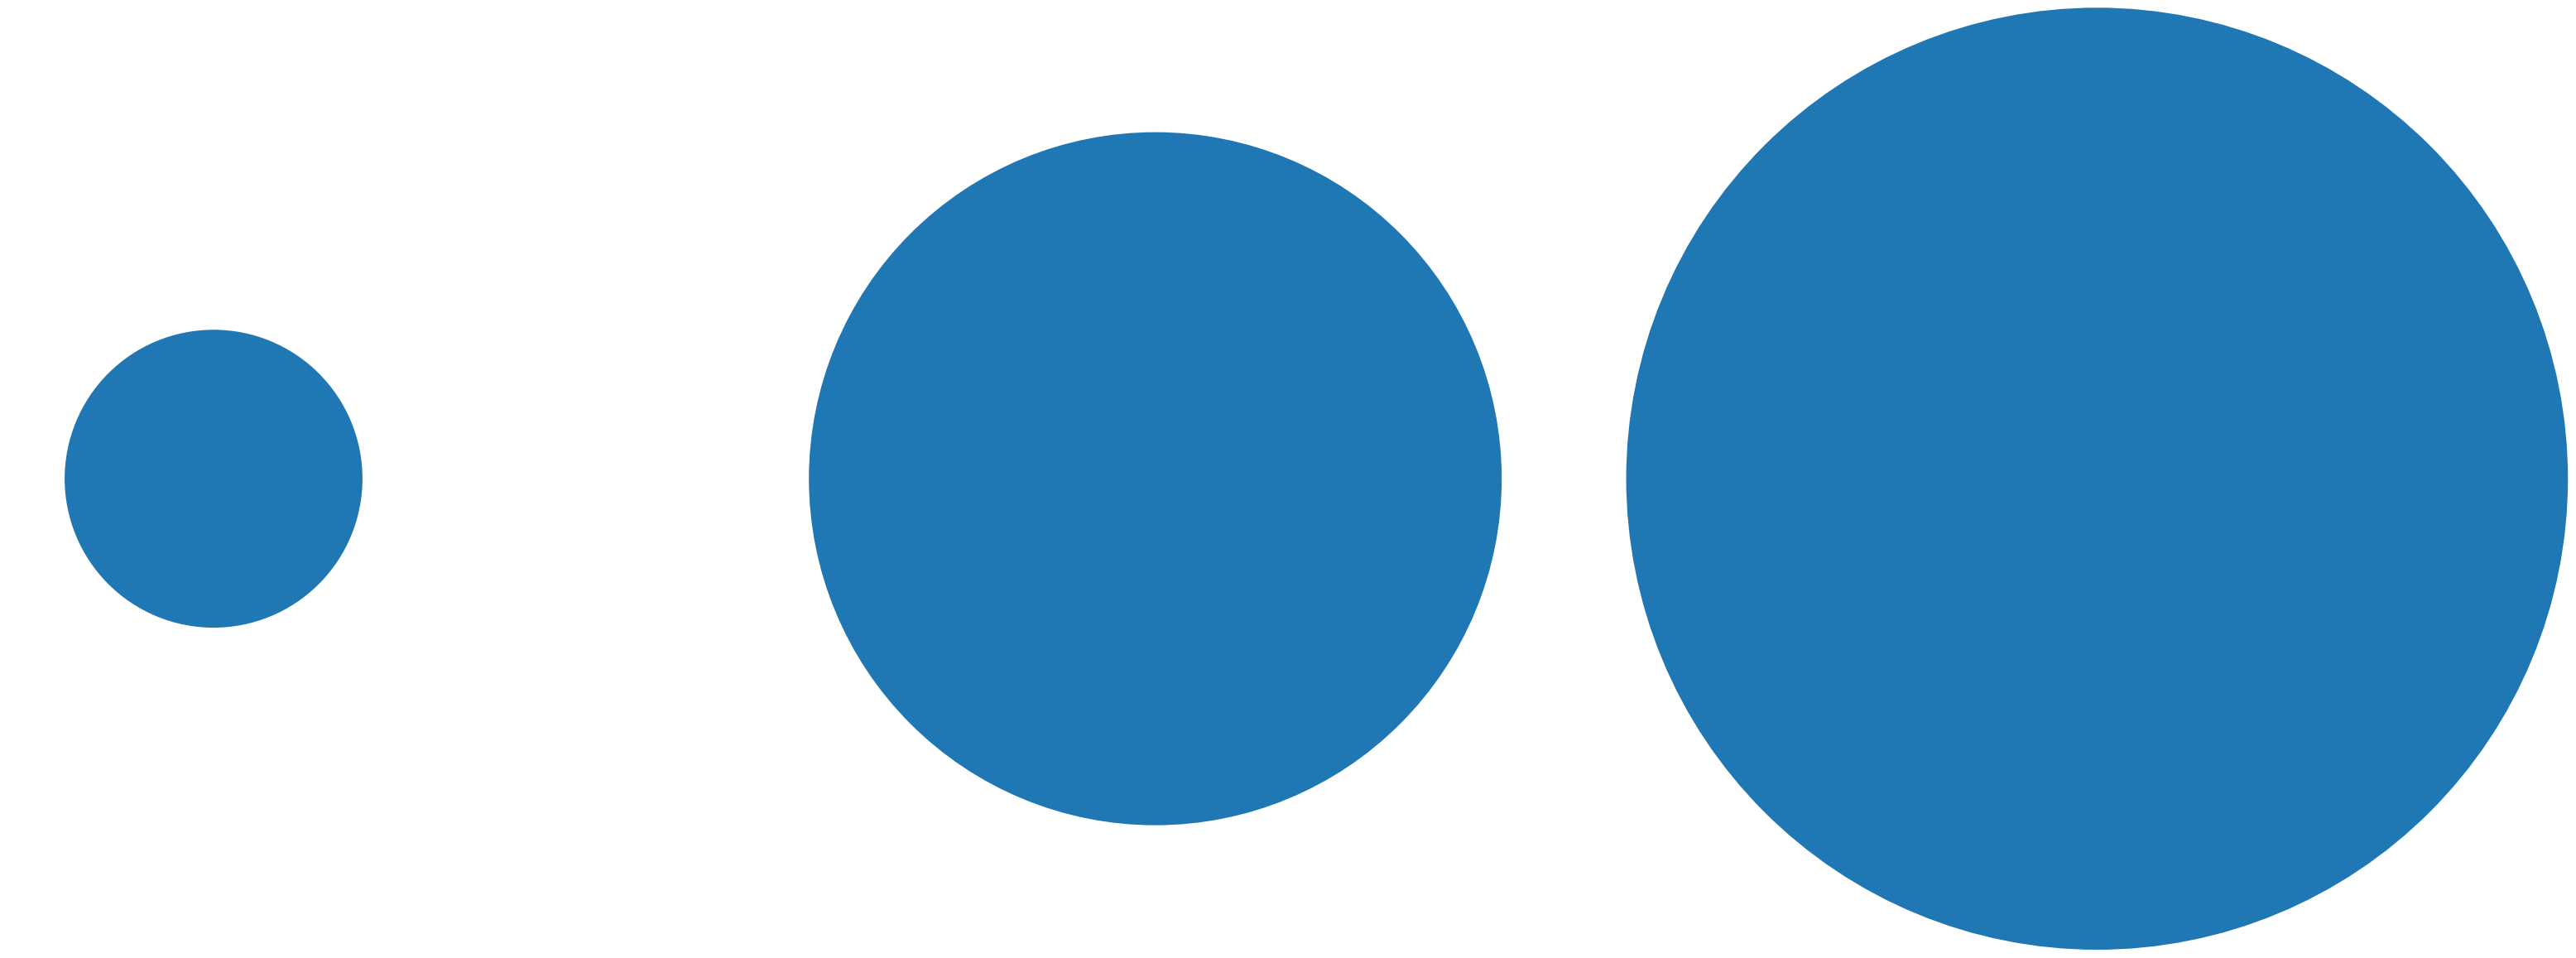

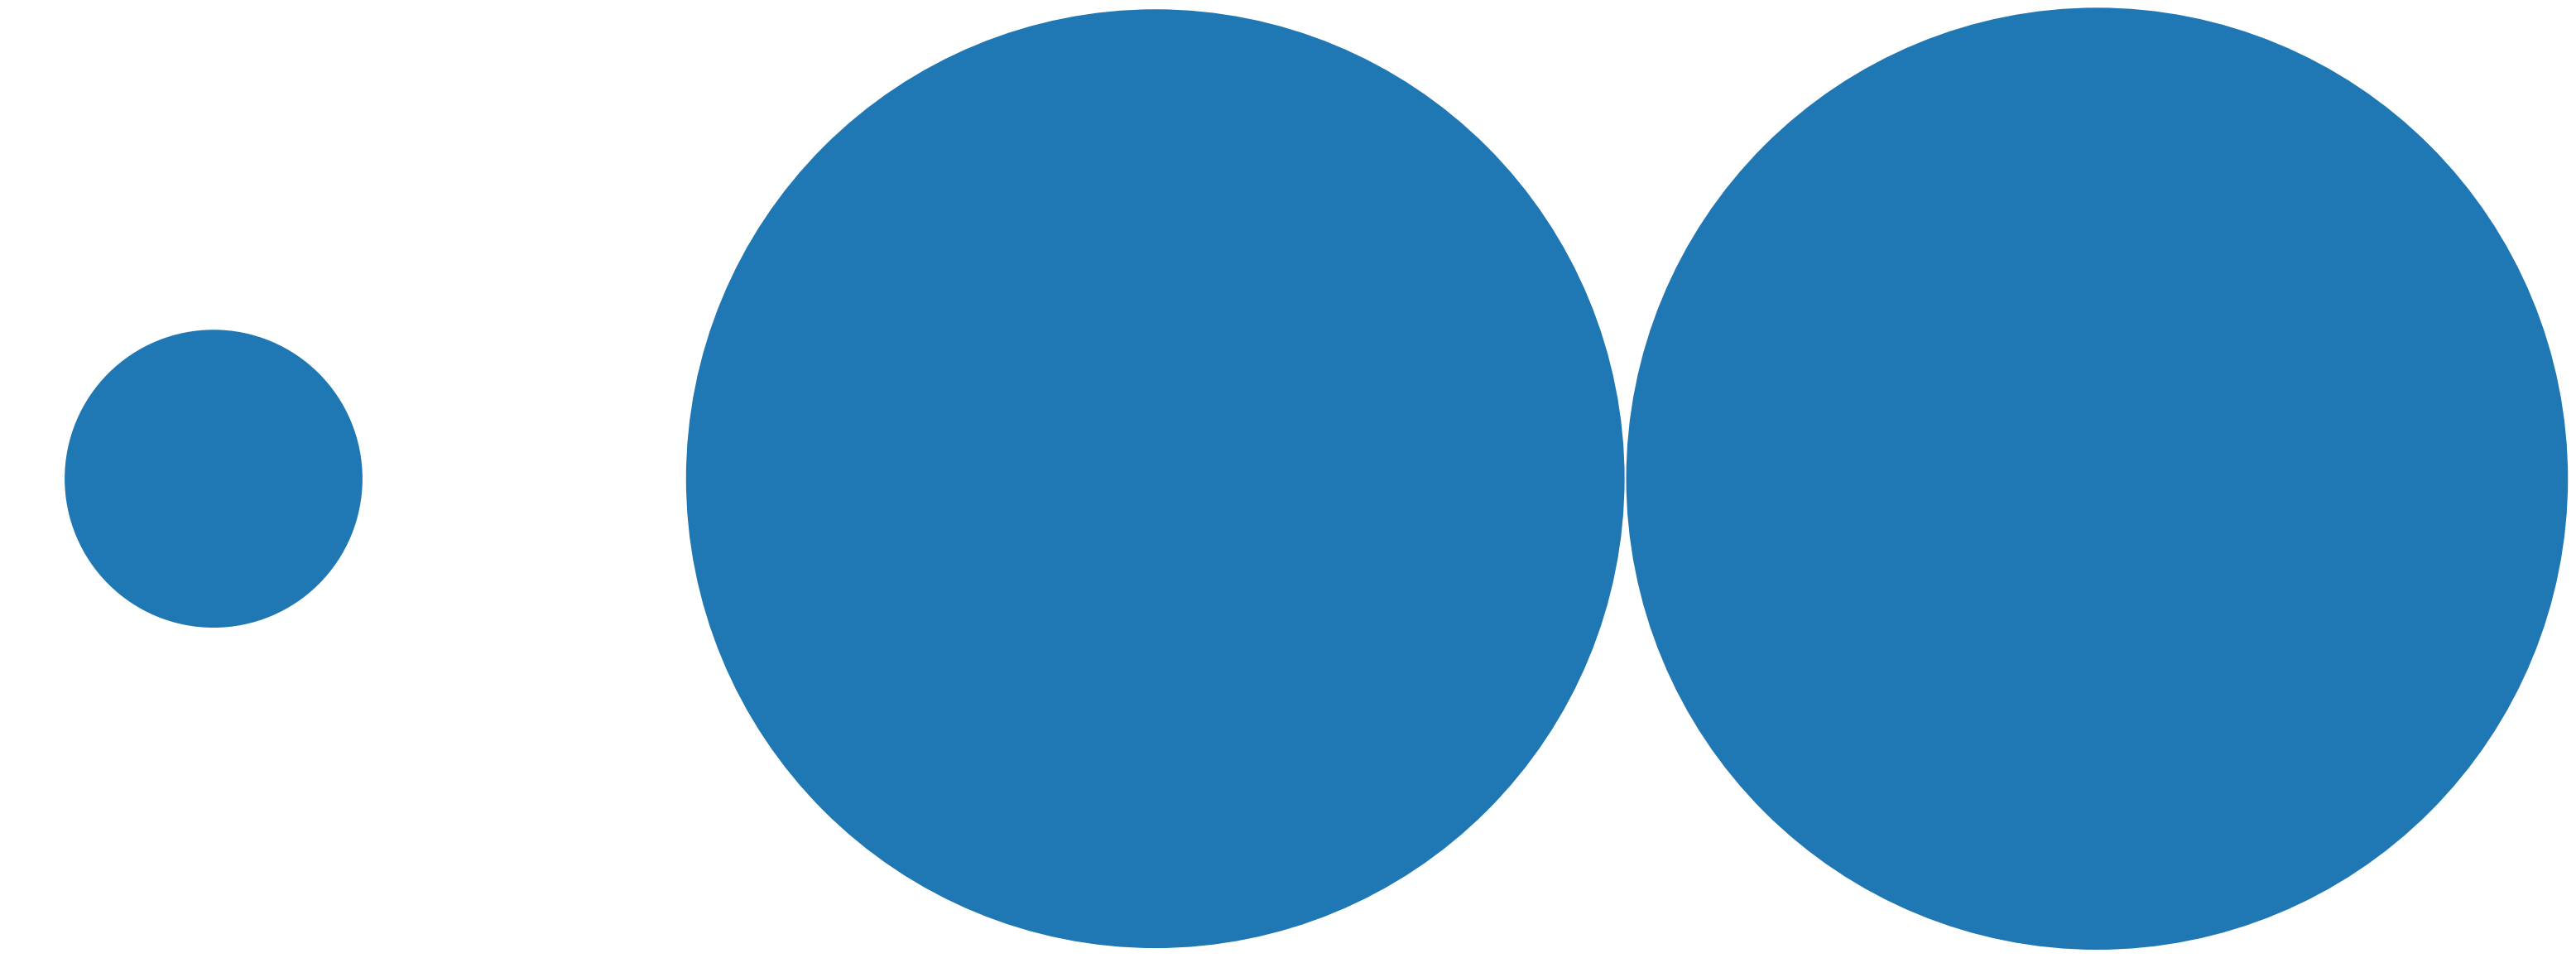

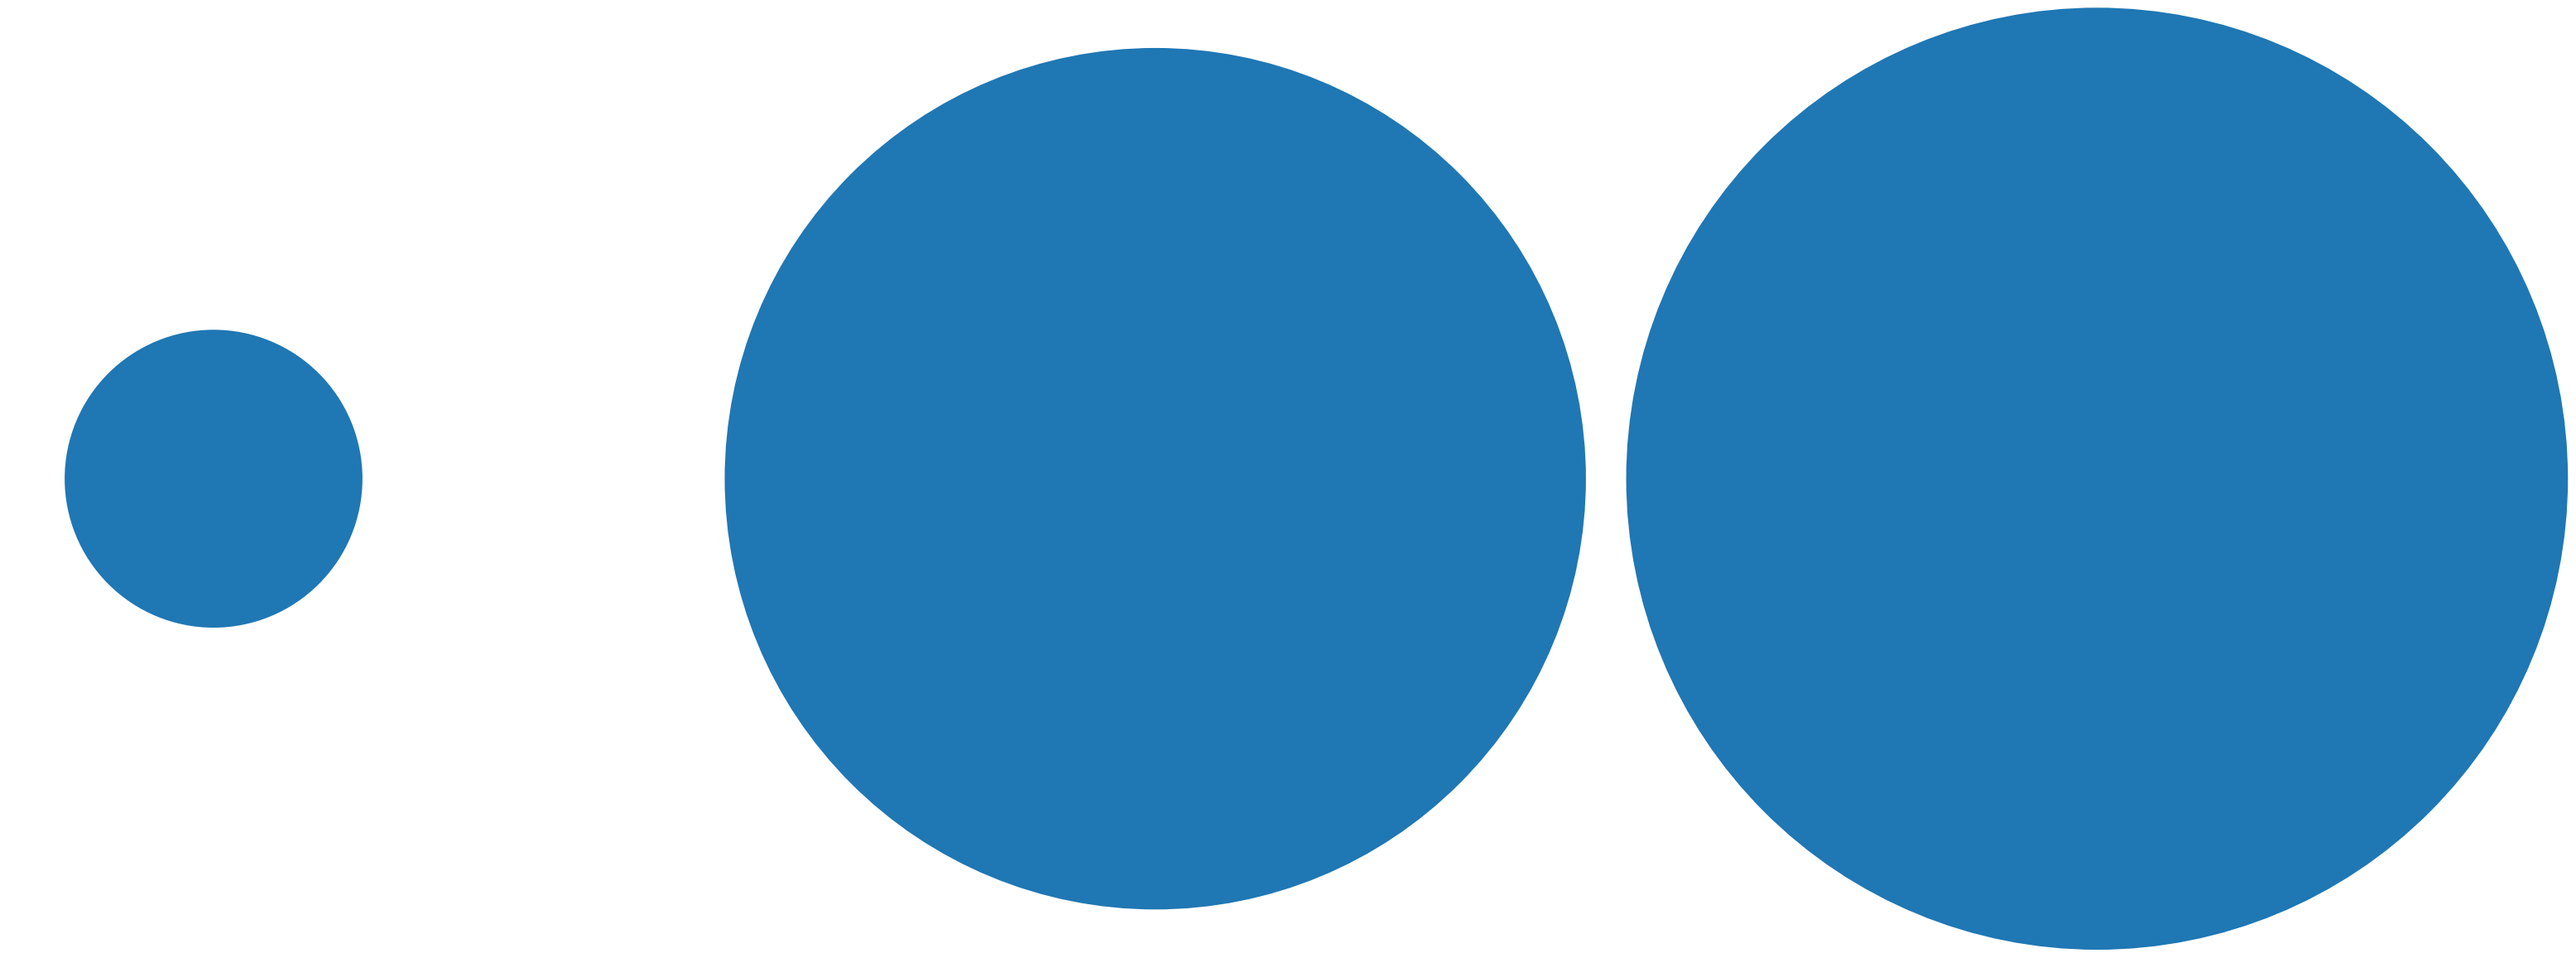

Lists have the same length: True


In [54]:
# TODO: put your code here. You can use multiple cells.
for _ in range(10):
    run_area_exp_once()
    
print("Lists have the same length:", len(perceived_area_list) == len(actual_area_list))

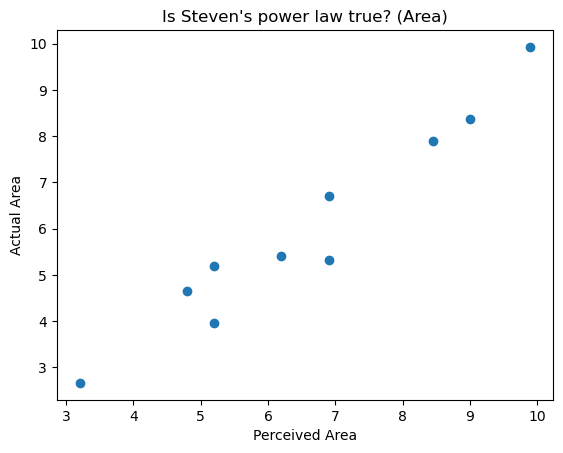

In [55]:
plt.scatter(x=perceived_area_list, y=actual_area_list)
plt.xlabel("Perceived Area")
plt.ylabel("Actual Area")
plt.title("Is Steven's power law true? (Area)")
plt.show()

In [64]:
param_area, param_cov_area = curve_fit(func, actual_area_list, perceived_area_list)
print("{:.2f} x^{:.2f} + {:.2f}".format(*param_area))

1.95 x^0.74 + -0.75


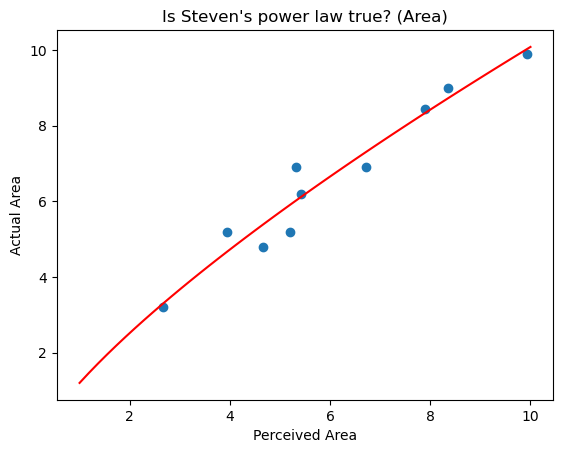

In [65]:

x_area = np.linspace(1, 10, 50)
y_area= func(x_area, *param_area)
plt.scatter( x=actual_area_list, y=perceived_area_list)
plt.plot(x_area, y_area, color='red')
plt.xlabel("Perceived Area")
plt.ylabel("Actual Area")
plt.title("Is Steven's power law true? (Area)")
plt.show()

What is your result? How are the exponents different from each other? 

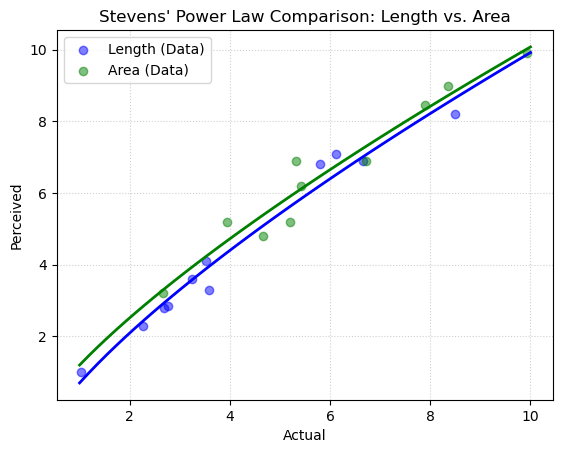

In [67]:
plt.scatter(actual_length_list, perceived_length_list, 
            color='blue', alpha=0.5, label='Length (Data)')
plt.plot(x_length, y_length, color='blue', linewidth=2)
plt.scatter(actual_area_list, perceived_area_list, 
            color='green', alpha=0.5, label='Area (Data)')
plt.plot(x_area, y_area, color='green', linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Perceived")
plt.title("Stevens' Power Law Comparison: Length vs. Area")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

The representations are very similar, suggesting that the perceived size is not affected by the visualization based on this specific simulation.

In [1]:
!jupyter nbconvert --output 'c04_notebook_Ciobanu_Sergiu_Tudor.html' --to html c04.ipynb

[NbConvertApp] Converting notebook c04.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 32 image(s).
[NbConvertApp] Writing 1746279 bytes to c04_notebook_Ciobanu_Sergiu_Tudor.html
